In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
RUTA_DELI = 'Estatal-Delitos-2015-2025_sep2025.csv'
ternium = pd.read_excel('data.xlsx', sheet_name='Viajes')
ternium.head()

,Viaje,Permiso,Shipment,Sociedad,Planta Origen,Tipo Planta,Origen,Destino,Ori-Dest-TT,Ori-Dest,...,Costo,Costo Prom,Variación,CostoxTn,Shp.Cost,Monto Real,Monto Falso,Monto Reparto,Moneda,Estatus
0,63343841.00,13191611.00,9063343841.00,TM01,MVA,Revestidos,COA,A. M. Aguascalientes,COA - A. M. Aguascalientes - 3 Ejes,COA - A. M. Aguascalientes,...,26754.05,NaN,NaN,831.00,5005114841.00,26754.05,0.00,2675.41,MXN,SH
1,63865156.00,13280679.00,9063865156.00,TM01,MVA,Revestidos,COA,A. M. Aguascalientes,COA - A. M. Aguascalientes - 3 Ejes,COA - A. M. Aguascalientes,...,25200.00,NaN,NaN,968.49,5005164047.00,23418.00,1782.00,0.00,MXN,SH
2,63968044.00,13299662.00,9063968044.00,TM01,MVA,Revestidos,COA,A. M. Aguascalientes,COA - A. M. Aguascalientes - 3 Ejes,COA - A. M. Aguascalientes,...,30821.79,NaN,NaN,831.00,5005174621.00,30821.79,0.00,3082.18,MXN,SH
3,64443396.00,13394064.00,9064443396.00,TM01,MVA,Revestidos,COA,A. M. Aguascalientes,COA - A. M. Aguascalientes - 3 Ejes,COA - A. M. Aguascalientes,...,25378.74,NaN,NaN,831.00,5005229756.00,25378.74,0.00,2537.87,MXN,SH
4,64814865.00,13447405.00,9064814865.00,TM01,MVA,Revestidos,COA,A. M. Aguascalientes,COA - A. M. Aguascalientes - 3 Ejes,COA - A. M. Aguascalientes,...,27571.50,NaN,NaN,900.00,5005261017.00,27571.50,0.00,2757.15,MXN,SH


In [3]:
ternium.columns

Index(['Viaje', 'Permiso', 'Shipment', 'Sociedad', 'Planta Origen',
       'Tipo Planta', 'Origen', 'Destino', 'Ori-Dest-TT', 'Ori-Dest',
       'Deposito Origen', 'Tipo planta', 'Desc Org. Apt', 'TPP', 'Desc TPP',
       'Transp.Leg', 'Nombre', 'TpoTrn.APT', 'TpoTrn.Leg', 'Desc TpoTrn',
       'Tipo transporte', 'Garantía', 'Flete Falso (KG)', 'Flete Falso (MXN)',
       'Flete Falso (USD)', 'TpoVje', 'TpoSrv', 'TpoPermiso', 'F.Salida',
       'H.Salida', '#Remitos', 'Modal.', 'Peso Total (kg)', 'Costo',
       'Costo Prom', 'Variación', 'CostoxTn', 'Shp.Cost', 'Monto Real',
       'Monto Falso', 'Monto Reparto', 'Moneda', 'Estatus'],
      dtype='object')

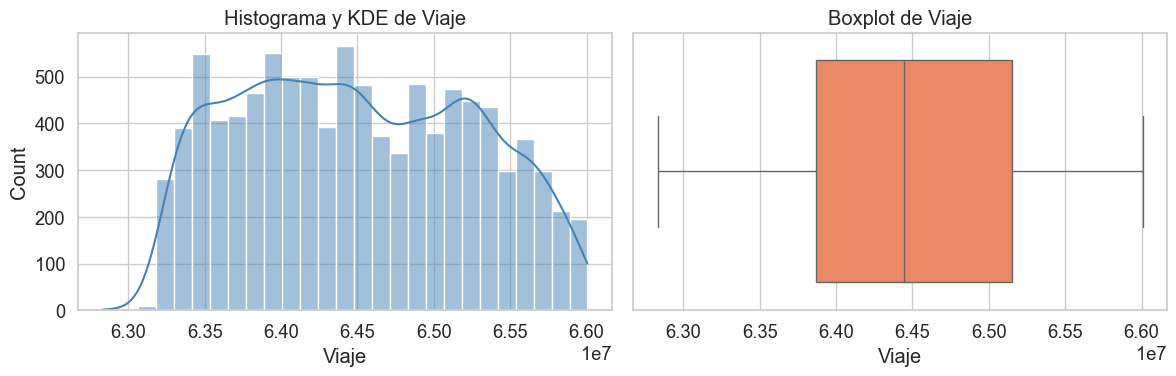

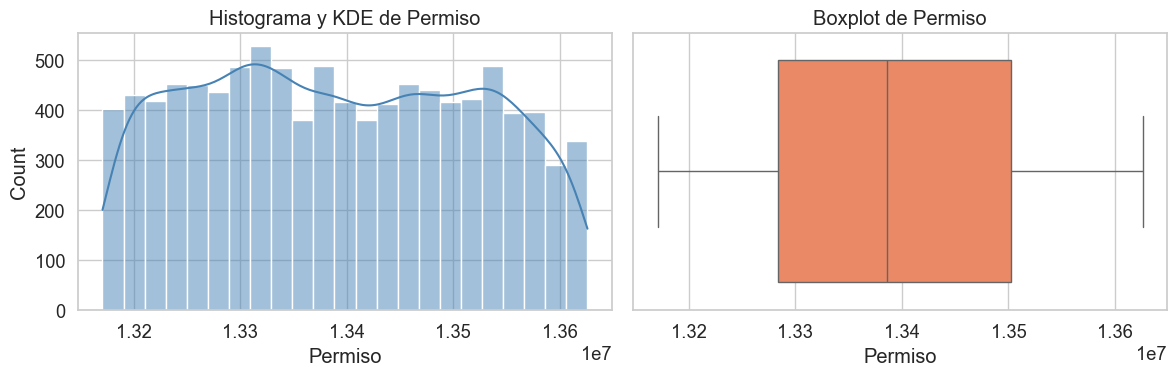

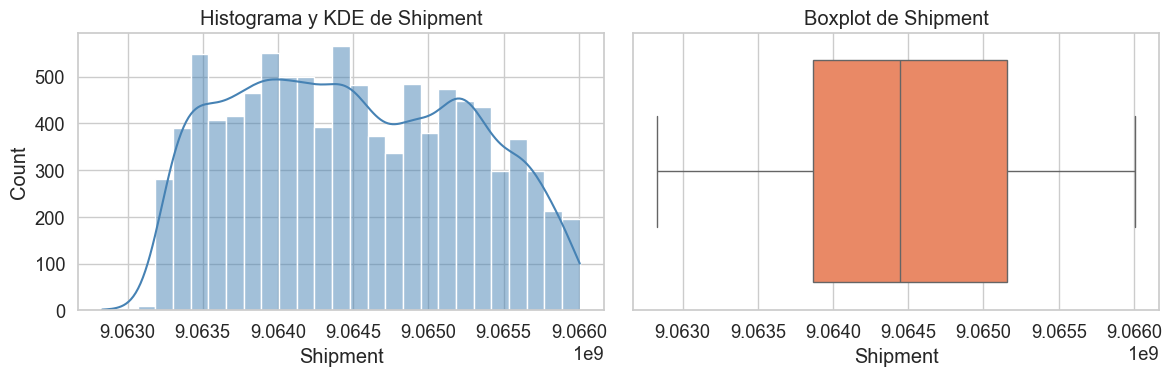

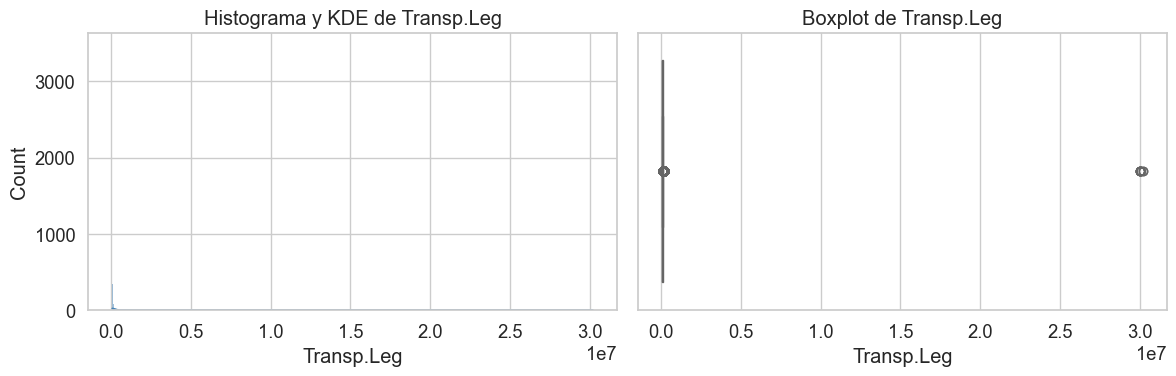

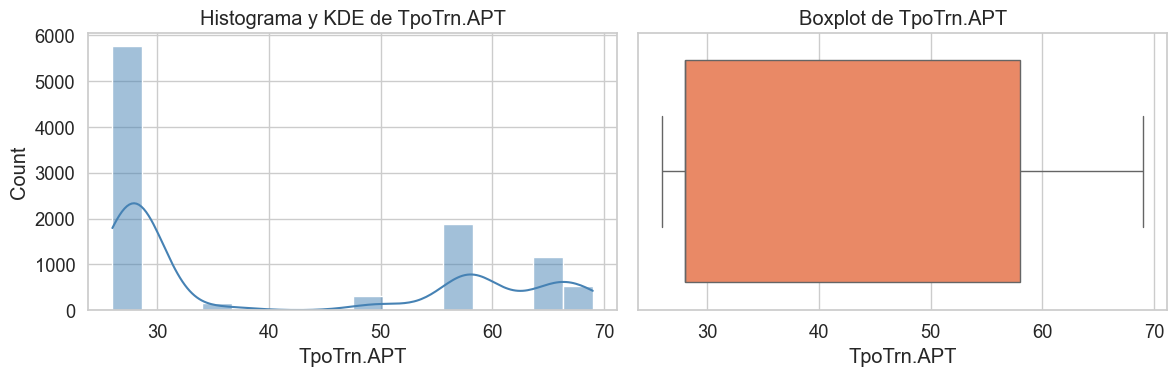

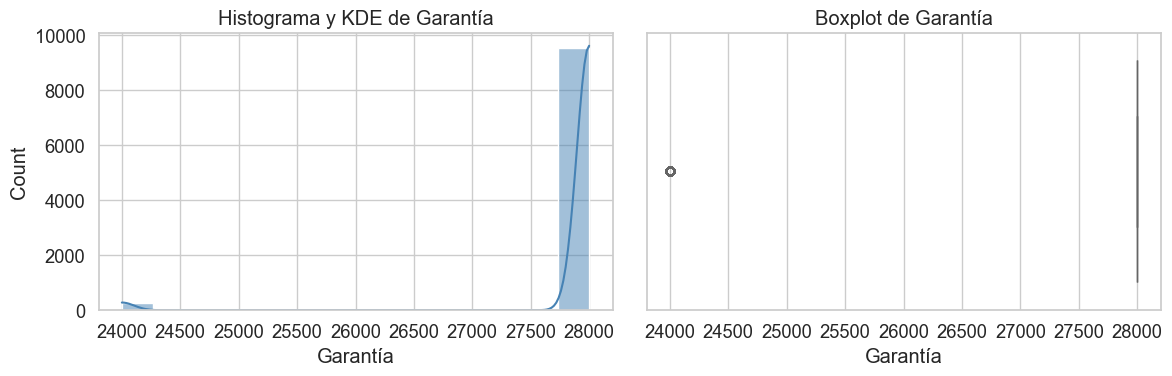

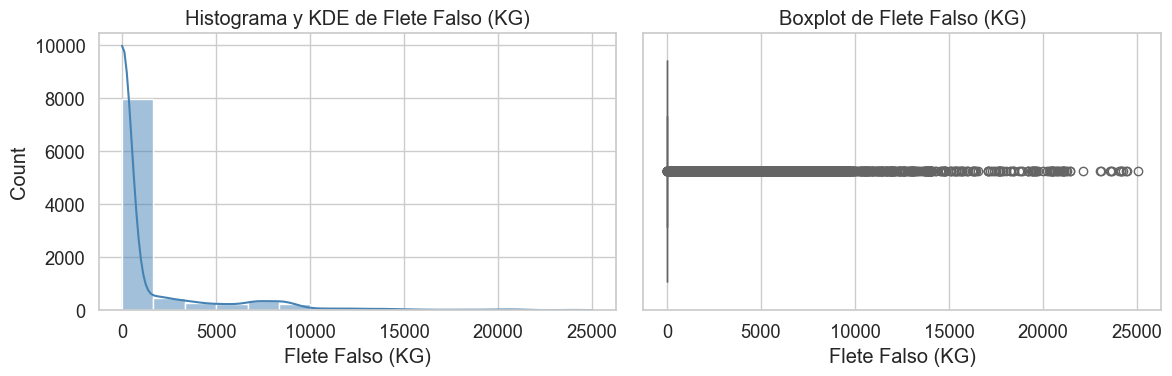

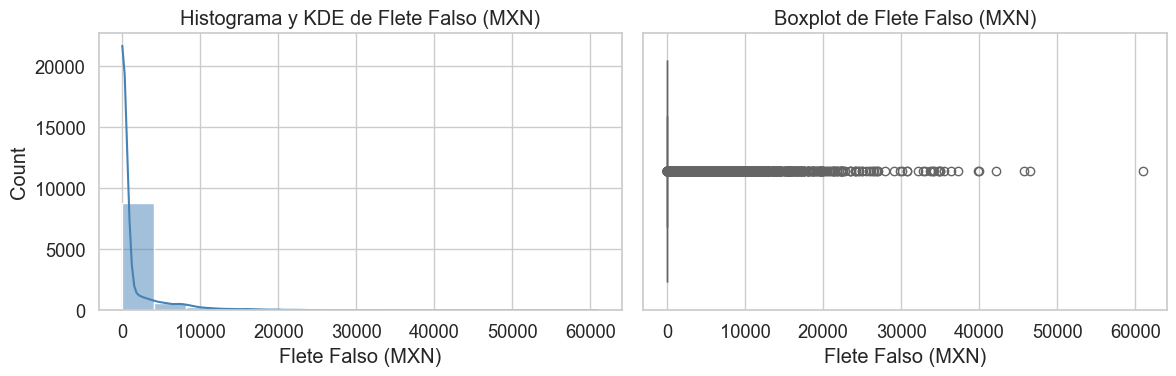

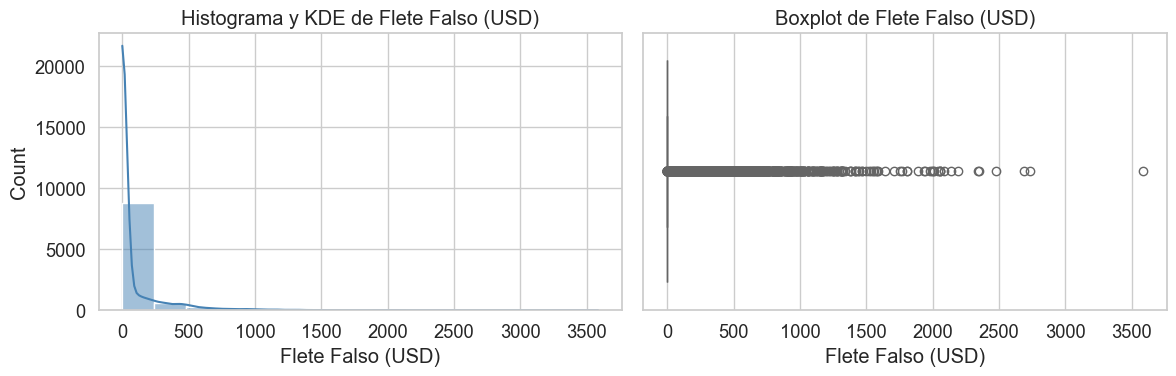

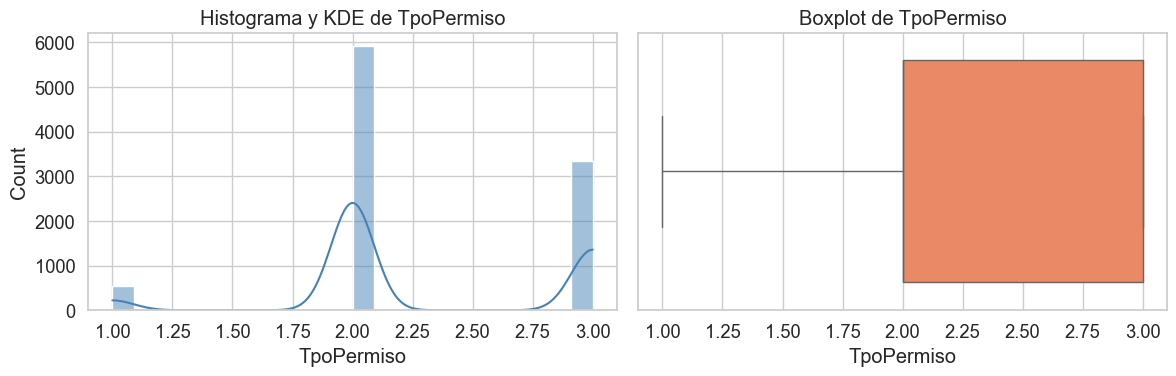

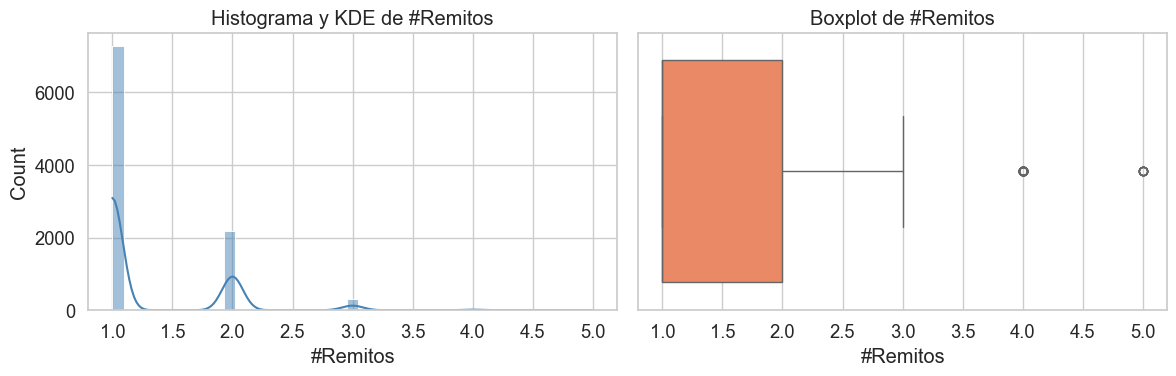

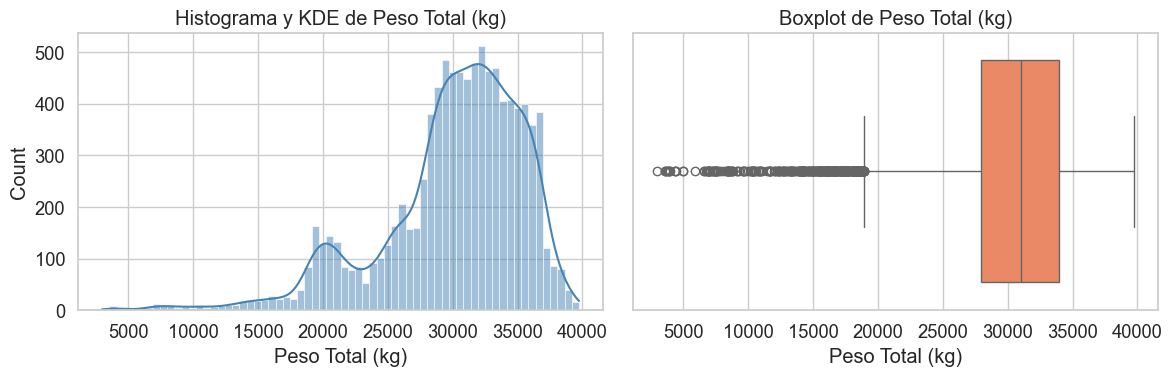

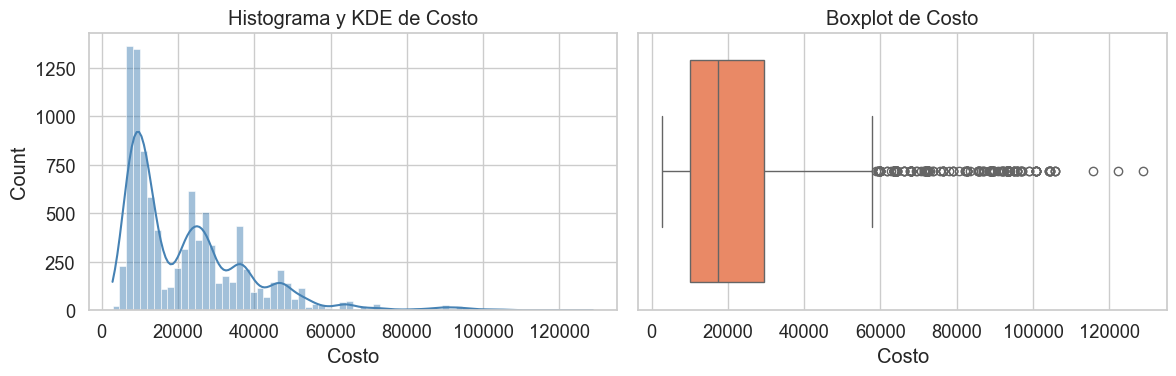

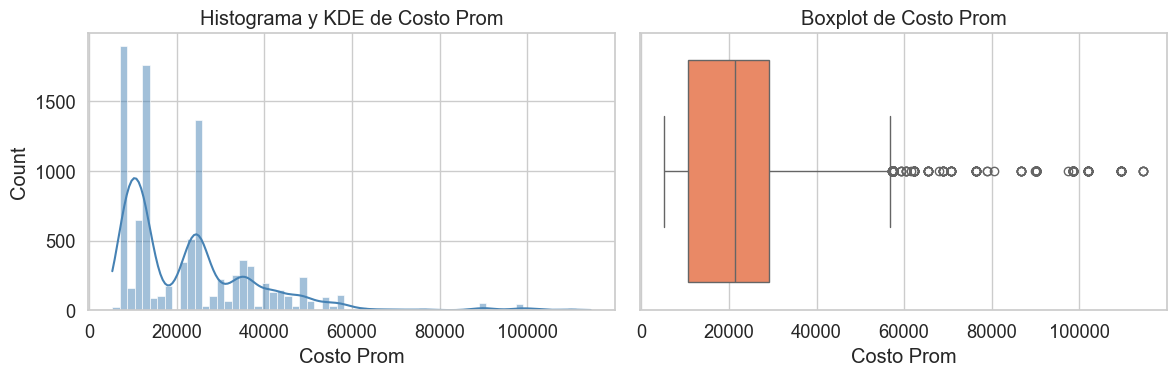

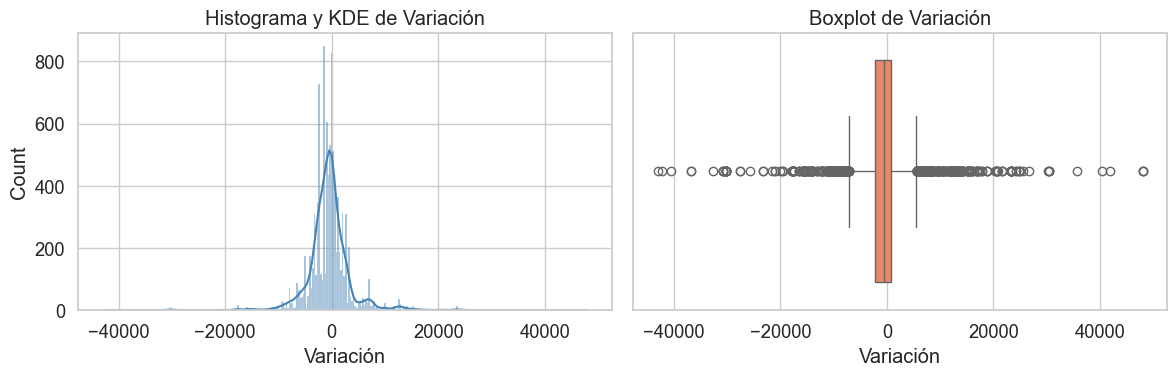

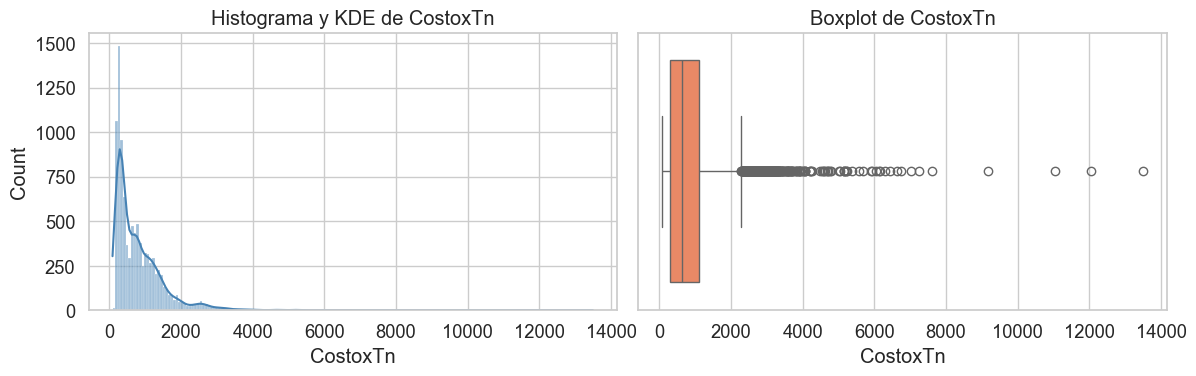

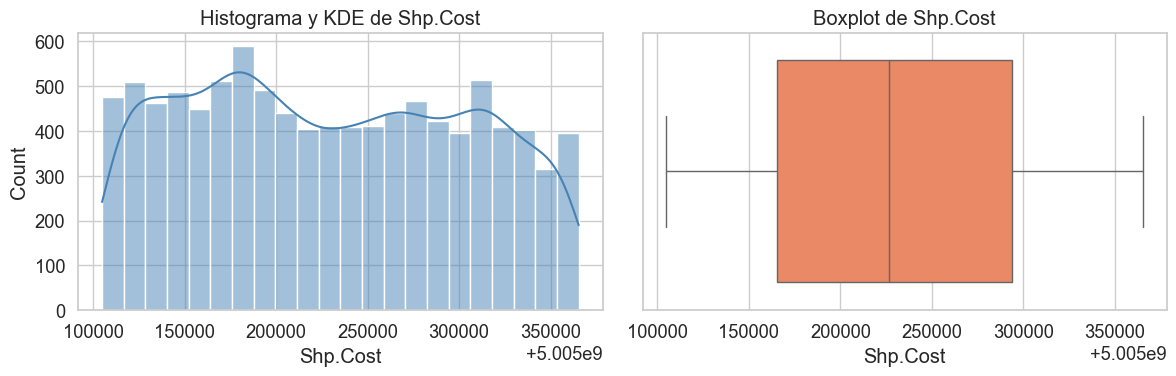

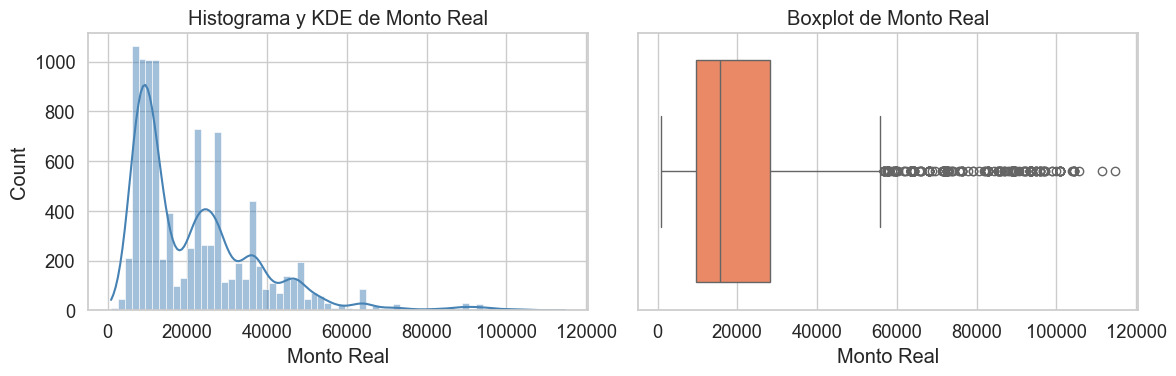

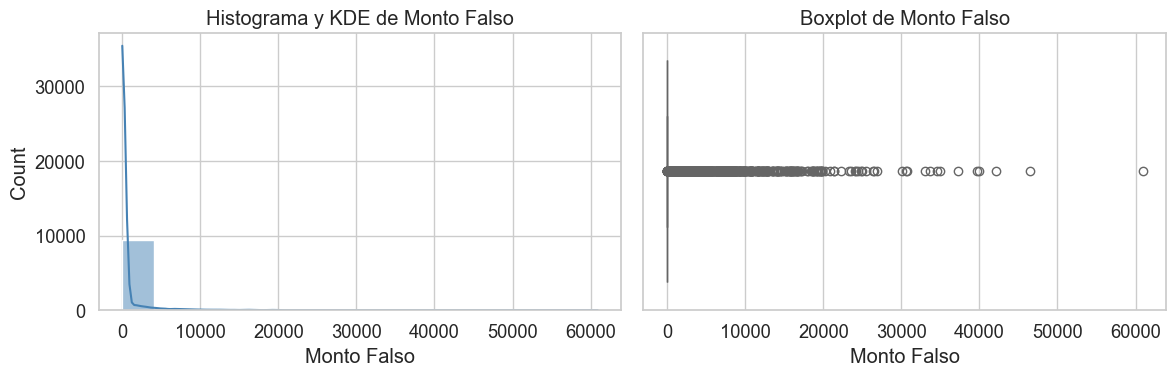

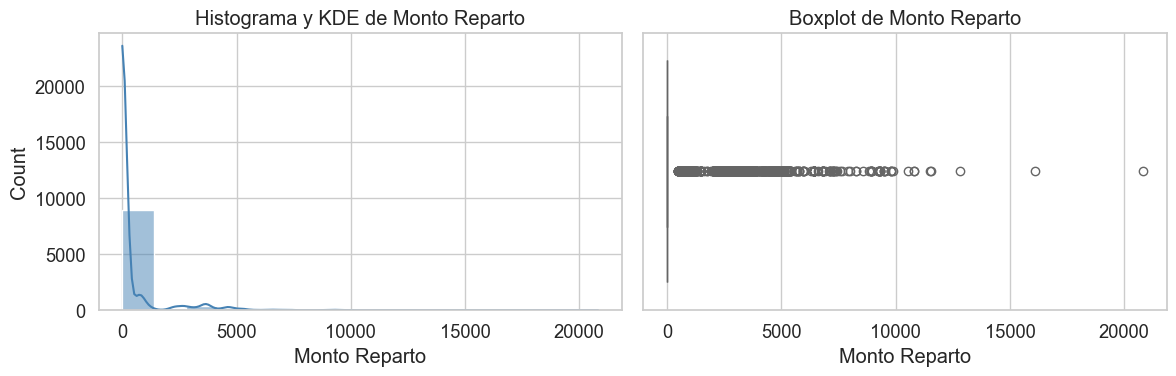

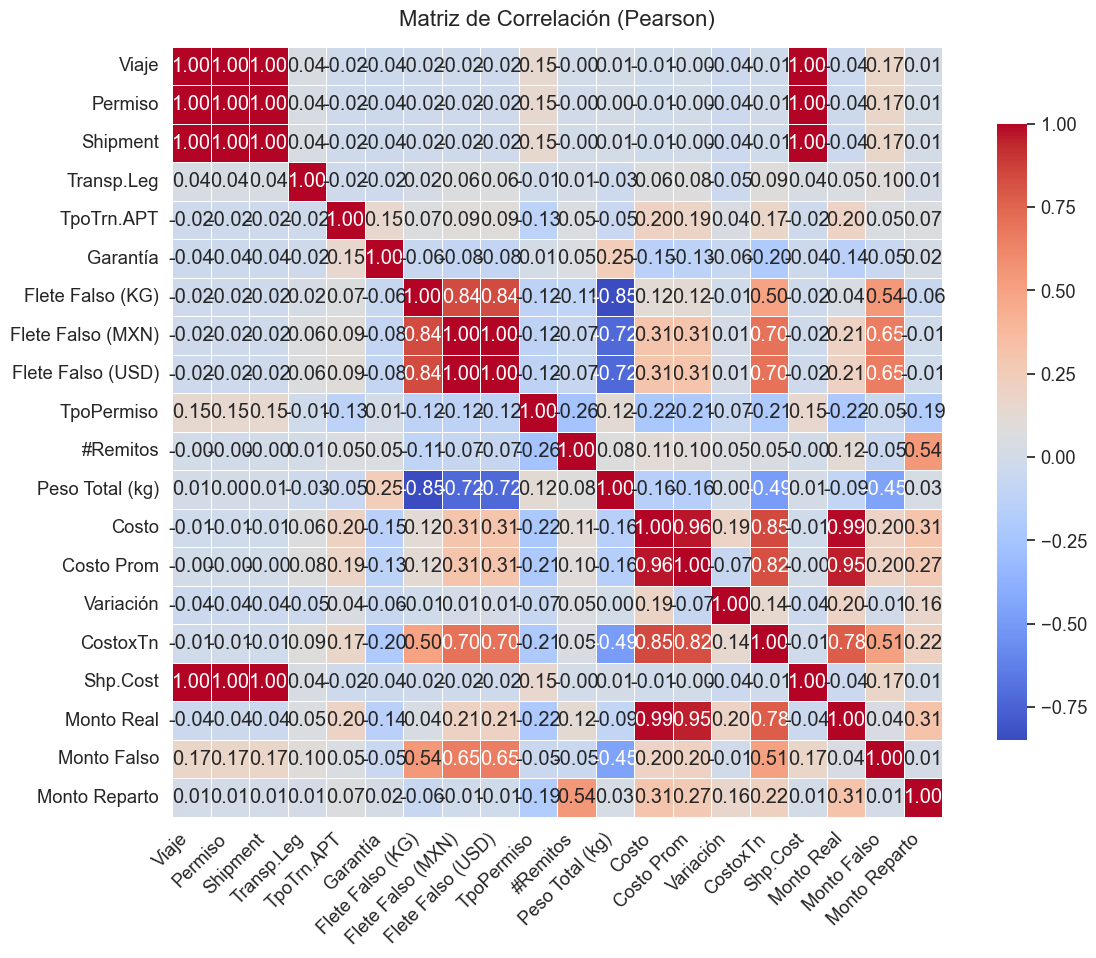

Correlación Pearson:
                    Viaje  Permiso  Shipment  Transp.Leg  TpoTrn.APT  Garantía  \
Viaje               1.00     1.00      1.00        0.04       -0.02     -0.04   
Permiso             1.00     1.00      1.00        0.04       -0.02     -0.04   
Shipment            1.00     1.00      1.00        0.04       -0.02     -0.04   
Transp.Leg          0.04     0.04      0.04        1.00       -0.02     -0.02   
TpoTrn.APT         -0.02    -0.02     -0.02       -0.02        1.00      0.15   
Garantía           -0.04    -0.04     -0.04       -0.02        0.15      1.00   
Flete Falso (KG)   -0.02    -0.02     -0.02        0.02        0.07     -0.06   
Flete Falso (MXN)  -0.02    -0.02     -0.02        0.06        0.09     -0.08   
Flete Falso (USD)  -0.02    -0.02     -0.02        0.06        0.09     -0.08   
TpoPermiso          0.14     0.15      0.14       -0.01       -0.13      0.01   
#Remitos           -0.00    -0.00     -0.00        0.01        0.05      0.05   
Peso T

,Media,Mediana,Moda,Varianza,Desviación Std,Coef. Variación (%),Mínimo,Máximo,Rango,Asimetría,Curtosis,Sesgo (z),Sesgo Significativo,p Shapiro,p D’Agostino,p Kolmogorov–Smirnov,Normal (α=0.05),p-valor,Outliers (IQR)
Viaje,64499205.14,64447215.00,62831274.00,568163265246.29,753766.05,1.17,62831274.00,66006156.00,3174882.00,0.12,-1.10,2.05,True,0.00,0.00,0.00,False,NaN,0.00
Permiso,13391345.92,13386448.50,13170623.00,16315715829.15,127732.99,0.95,13170623.00,13625947.00,455324.00,0.06,-1.17,1.00,False,0.00,0.00,0.00,False,NaN,0.00
Shipment,9064499205.14,9064447215.00,9062831274.00,568163265246.29,753766.05,0.01,9062831274.00,9066006156.00,3174882.00,0.12,-1.10,2.05,True,0.00,0.00,0.00,False,NaN,0.00
Transp.Leg,143417.64,103079.00,103079.00,912476695572.35,955236.46,666.05,100128.00,30166370.00,30066242.00,31.26,975.69,516.00,True,0.00,0.00,0.00,False,NaN,2128.00
TpoTrn.APT,41.14,28.00,28.00,271.14,16.47,40.02,26.00,69.00,43.00,0.53,-1.56,8.83,True,0.00,0.00,0.00,False,NaN,0.00
Garantía,27886.65,28000.00,28000.00,440610.73,663.79,2.38,24000.00,28000.00,4000.00,-5.69,30.33,-93.86,True,0.00,0.00,0.00,False,NaN,278.00
Flete Falso (KG),1302.87,0.00,0.00,10381085.16,3221.97,247.30,0.00,25030.00,25030.00,3.24,12.24,53.43,True,0.00,0.00,0.00,False,NaN,2403.00
Flete Falso (MXN),1275.83,0.00,0.00,13573008.88,3684.16,288.77,0.00,60961.66,60961.66,4.92,35.13,81.19,True,0.00,0.00,0.00,False,NaN,2403.00
Flete Falso (USD),75.05,0.00,0.00,46965.43,216.72,288.77,0.00,3585.98,3585.98,4.92,35.13,81.19,True,0.00,0.00,0.00,False,NaN,2403.00
TpoPermiso,2.29,2.00,2.00,0.32,0.56,24.57,1.00,3.00,2.00,-0.04,-0.53,-0.71,False,0.00,0.00,0.00,False,NaN,0.00


In [4]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

def analisis_estadistico_avanzado(df, plot=True, figsize_corr=(12,9)):

    df_num = df.select_dtypes(include=[np.number]).dropna()
    resumen = pd.DataFrame(index=df_num.columns)

    resumen['Media'] = df_num.mean()
    resumen['Mediana'] = df_num.median()
    resumen['Moda'] = [df_num[col].mode().iloc[0] if not df_num[col].mode().empty else np.nan for col in df_num.columns]
    resumen['Varianza'] = df_num.var()
    resumen['Desviación Std'] = df_num.std()
    resumen['Coef. Variación (%)'] = (df_num.std() / df_num.mean()) * 100
    resumen['Mínimo'] = df_num.min()
    resumen['Máximo'] = df_num.max()
    resumen['Rango'] = df_num.max() - df_num.min()

    resumen['Asimetría'] = df_num.skew()
    resumen['Curtosis'] = df_num.kurtosis()

    resumen['Sesgo (z)'] = resumen['Asimetría'] / (6 / np.sqrt(df_num.shape[0]))
    resumen['Sesgo Significativo'] = resumen['Sesgo (z)'].abs() > 1.96

    shapiro_p, dagostino_p, ks_p = [], [], []
    for col in df_num.columns:
        data = df_num[col].sample(n=min(5000, len(df_num[col])), random_state=42)
        try:
            shapiro_p.append(stats.shapiro(data)[1])
            dagostino_p.append(stats.normaltest(data)[1])
            ks_p.append(stats.kstest(data, 'norm', args=(data.mean(), data.std()))[1])
        except:
            shapiro_p.append(np.nan)
            dagostino_p.append(np.nan)
            ks_p.append(np.nan)
    resumen['p Shapiro'] = shapiro_p
    resumen['p D’Agostino'] = dagostino_p
    resumen['p Kolmogorov–Smirnov'] = ks_p
    resumen['Normal (α=0.05)'] = resumen[['p Shapiro', 'p D’Agostino', 'p Kolmogorov–Smirnov']].gt(0.05).all(axis=1)

    if df_num.shape[1] > 1:
        try:
            resumen.loc['Test Levene', 'p-valor'] = stats.levene(*[df_num[c] for c in df_num.columns])[1]
            resumen.loc['Test Bartlett', 'p-valor'] = stats.bartlett(*[df_num[c] for c in df_num.columns])[1]
        except Exception:
            resumen.loc['Test Levene', 'p-valor'] = np.nan
            resumen.loc['Test Bartlett', 'p-valor'] = np.nan

    corr_pearson = df_num.corr(method='pearson')
    corr_spearman = df_num.corr(method='spearman')
    corr_kendall = df_num.corr(method='kendall')

    outliers = {}
    for col in df_num.columns:
        Q1, Q3 = np.percentile(df_num[col], [25, 75])
        IQR = Q3 - Q1
        low, high = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        outliers[col] = ((df_num[col] < low) | (df_num[col] > high)).sum()
    resumen['Outliers (IQR)'] = pd.Series(outliers)

    if plot:
        sns.set(style="whitegrid", font_scale=1.2)
        
        for col in df_num.columns:
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            
            sns.histplot(df_num[col], kde=True, color='steelblue', ax=axes[0])
            axes[0].set_title(f'Histograma y KDE de {col}')
            axes[0].set_xlabel(col)
            

            sns.boxplot(x=df_num[col], color='coral', ax=axes[1])
            axes[1].set_title(f'Boxplot de {col}')
            plt.tight_layout()
            plt.show()

        plt.figure(figsize=figsize_corr)
        sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', fmt=".2f", square=True,
                    cbar_kws={'shrink': .8}, linewidths=.5)
        plt.title("Matriz de Correlación (Pearson)", fontsize=16, pad=15)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.show()

    print("Correlación Pearson:\n", corr_pearson.round(3))
    print("Correlación Spearman:\n", corr_spearman.round(3))
    print("Correlación Kendall:\n", corr_kendall.round(3))

    return resumen.round(4)

resumen = analisis_estadistico_avanzado(ternium, plot=True, figsize_corr=(14,10))
resumen

In [5]:
ternium = ternium[['Ori-Dest','Planta Origen','Origen','Destino','Transp.Leg','Nombre','TpoTrn.APT','TpoTrn.Leg','Tipo transporte','Garantía','Flete Falso (KG)','Flete Falso (MXN)','TpoVje','TpoSrv','TpoPermiso','F.Salida','H.Salida','#Remitos','Peso Total (kg)','Costo','Costo Prom','Variación','CostoxTn','Monto Real','Monto Falso','Monto Reparto']]
ternium.head()

,Ori-Dest,Planta Origen,Origen,Destino,Transp.Leg,Nombre,TpoTrn.APT,TpoTrn.Leg,Tipo transporte,Garantía,...,H.Salida,#Remitos,Peso Total (kg),Costo,Costo Prom,Variación,CostoxTn,Monto Real,Monto Falso,Monto Reparto
0,COA - A. M. Aguascalientes,MVA,COA,A. M. Aguascalientes,100349.00,TRANSPORTES DE ACERO SA DE CV,28.00,01,3 Ejes,28000.00,...,23:08:00,2.00,32195.00,26754.05,NaN,NaN,831.00,26754.05,0.00,2675.41
1,COA - A. M. Aguascalientes,MVA,COA,A. M. Aguascalientes,106207.00,AUTO LINEAS LARROC S.A. DE C.V.,28.00,01,3 Ejes,28000.00,...,16:27:23,2.00,26020.00,25200.00,NaN,NaN,968.49,23418.00,1782.00,0.00
2,COA - A. M. Aguascalientes,MVA,COA,A. M. Aguascalientes,100349.00,TRANSPORTES DE ACERO SA DE CV,28.00,01,3 Ejes,28000.00,...,23:47:31,2.00,37090.00,30821.79,NaN,NaN,831.00,30821.79,0.00,3082.18
3,COA - A. M. Aguascalientes,MVA,COA,A. M. Aguascalientes,100349.00,TRANSPORTES DE ACERO SA DE CV,28.00,01,3 Ejes,28000.00,...,15:51:51,2.00,30540.00,25378.74,NaN,NaN,831.00,25378.74,0.00,2537.87
4,COA - A. M. Aguascalientes,MVA,COA,A. M. Aguascalientes,106207.00,AUTO LINEAS LARROC S.A. DE C.V.,28.00,01,3 Ejes,28000.00,...,18:48:14,2.00,30635.00,27571.50,NaN,NaN,900.00,27571.50,0.00,2757.15


## Features añadidos

Haciendo uso de google maps se hallaron las distancias (km) de ruta óptima y tiempo en auto (minutos) para cada ruta del dataset. Esto con el objetivo de hallar el costo por peso por km o el costo por peso por minuto para identificar aquellos viajes o rutas más costosas.

**IMPORTANTE:** Para la ruta 'NL - AM Mty Regional' no supimos ponerle distancia y tiempo, por lo que quedan como valores NaN. Por tanto, los viajes en esta ruta no contribuyen en todos los análisis, cálculos y concusiones en donde se tuvo en cuenta la distancia o el tiempo.

In [6]:
rutas = pd.read_excel('data.xlsx', sheet_name='Hoja1')

costo_x_tonelada_prom = []
for ruta in rutas['Ori-Dest']:
    cxt = ternium[ternium['Ori-Dest'] == ruta]['CostoxTn'].mean()
    costo_x_tonelada_prom.append(cxt)

ternium = ternium.merge(rutas, on='Ori-Dest', how='left') # añadir info de rutas al data set

rutas['costo_x_tonelada_prom'] = costo_x_tonelada_prom
rutas['costo_x_tonelada_prom_x_km'] = rutas['costo_x_tonelada_prom'] / rutas['Distancia']
rutas['costo_x_tonelada_prom_x_min'] = rutas['costo_x_tonelada_prom'] / rutas['Tiempo']
rutas

,Ori-Dest,Distancia,Tiempo,costo_x_tonelada_prom,costo_x_tonelada_prom_x_km,costo_x_tonelada_prom_x_min
0,NL - A. M. Aguascalientes,575.00,403.00,1133.10,1.97,2.81
1,NL - A. Metro Guadalajara,809.00,566.00,1849.17,2.29,3.27
2,NL - Acuña,479.00,329.00,931.12,1.94,2.83
3,NL - Altamira,487.00,330.00,684.68,1.41,2.07
4,NL - AM Mty Regional,NaN,NaN,276.90,NaN,NaN
...,...,...,...,...,...,...
59,COA - Matamoros,492.00,334.00,962.38,1.96,2.88
60,COA - Merida,2154.00,1620.00,3683.90,1.71,2.27
61,COA - Mexicali,1977.00,1155.00,3306.74,1.67,2.86
62,COA - Silao,773.00,527.00,1173.42,1.52,2.23


In [7]:
variables_numericas = ternium.select_dtypes(include=[np.number])
variables_numericas.corr()

,Transp.Leg,TpoTrn.APT,Garantía,Flete Falso (KG),Flete Falso (MXN),TpoPermiso,#Remitos,Peso Total (kg),Costo,Costo Prom,Variación,CostoxTn,Monto Real,Monto Falso,Monto Reparto,Distancia,Tiempo
Transp.Leg,1.00,-0.02,-0.02,0.02,0.06,-0.01,0.01,-0.03,0.06,0.08,-0.05,0.09,0.05,0.10,0.01,0.07,0.07
TpoTrn.APT,-0.02,1.00,0.14,0.08,0.11,-0.14,0.06,-0.07,0.22,0.19,0.04,0.19,0.22,0.06,0.08,0.15,0.15
Garantía,-0.02,0.14,1.00,-0.07,-0.09,0.02,0.04,0.25,-0.15,-0.13,-0.06,-0.21,-0.15,-0.06,0.01,-0.16,-0.17
Flete Falso (KG),0.02,0.08,-0.07,1.00,0.84,-0.14,-0.09,-0.84,0.15,0.12,-0.01,0.51,0.06,0.54,-0.05,0.11,0.11
Flete Falso (MXN),0.06,0.11,-0.09,0.84,1.00,-0.13,-0.06,-0.71,0.33,0.31,0.01,0.70,0.23,0.65,-0.01,0.29,0.30
TpoPermiso,-0.01,-0.14,0.02,-0.14,-0.13,1.00,-0.27,0.14,-0.26,-0.21,-0.07,-0.24,-0.25,-0.06,-0.19,-0.22,-0.22
#Remitos,0.01,0.06,0.04,-0.09,-0.06,-0.27,1.00,0.06,0.14,0.10,0.05,0.07,0.15,-0.04,0.55,0.13,0.14
Peso Total (kg),-0.03,-0.07,0.25,-0.84,-0.71,0.14,0.06,1.00,-0.18,-0.16,0.00,-0.50,-0.12,-0.45,0.02,-0.15,-0.15
Costo,0.06,0.22,-0.15,0.15,0.33,-0.26,0.14,-0.18,1.00,0.96,0.19,0.86,0.99,0.21,0.32,0.93,0.94
Costo Prom,0.08,0.19,-0.13,0.12,0.31,-0.21,0.10,-0.16,0.96,1.00,-0.07,0.82,0.95,0.20,0.27,0.95,0.96


## Peligrosidad de Ruta

In [8]:
import pandas as pd
import numpy as np
import re
import unicodedata

RUTA_VIAJES = ternium

def strip_accents(s: str) -> str:
    if s is None:
        return ""
    s = str(s)
    # normalización unicode
    s = "".join(c for c in unicodedata.normalize("NFKD", s) if unicodedata.category(c) != "Mn")
    # reemplazos básicos de mojibake / símbolos raros
    s = s.replace("·", "o")  # Yucat·n -> Yucatan (fallback)
    s = s.replace("Ø", "o").replace("Û", "u").replace("Ì", "i").replace("È", "E").replace("ì", "i")
    s = s.replace("Â", "")   # residuos de bytes mal decodificados
    # a minúsculas
    s = s.lower()
    # dejar solo letras, números y espacios
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    # colapsar espacios
    s = re.sub(r"\s+", " ", s).strip()
    return s

def canonical_state_key(raw: str) -> str:
    s = strip_accents(raw)
    if not s:
        return ""

    # sinónimos / correcciones comunes
    replacements = {
        "estado de mexico": "mexico",
        "edo de mexico": "mexico",
        "edo. de mexico": "mexico",
        "edomex": "mexico",
        "cdmx": "ciudad de mexico",
        "ciudad de mexic o": "ciudad de mexico",
        "coahuila": "coahuila de zaragoza",
        "veracruz": "veracruz de ignacio de la llave",
        "michoacan": "michoacan de ocampo",
        "queretaro": "queretaro",  # ya sin acento
        "nuevo leon": "nuevo leon",
        "san luis potosi": "san luis potosi",
        "yucatan": "yucatan",
        "baja california sur": "baja california sur",
        "baja california": "baja california",
        "mexico": "mexico",  # (Estado de México)
    }

    # match exacto de catálogo sin acentos
    catalog = {
        "aguascalientes","baja california","baja california sur","campeche","chiapas","chihuahua",
        "ciudad de mexico","coahuila de zaragoza","colima","durango","guanajuato","guerrero",
        "hidalgo","jalisco","mexico","michoacan de ocampo","morelos","nayarit","nuevo leon",
        "oaxaca","puebla","queretaro","quintana roo","san luis potosi","sinaloa","sonora",
        "tabasco","tamaulipas","tlaxcala","veracruz de ignacio de la llave","yucatan","zacatecas"
    }

    # si ya es uno del catálogo, lo regresamos
    if s in catalog:
        return s

    # aplicar replacements si el string completo es un alias
    if s in replacements:
        key = replacements[s]
        return key if key in catalog else key

    # heurística: si contiene tokens clave
    tokens = s.split()

    # casos “mexico” ambiguos: puede venir "mexico" o contener "mexico"
    if "ciudad" in tokens and "mexico" in tokens:
        return "ciudad de mexico"
    if "mexico" in tokens:
        return "mexico"

    # compuestos largos
    if "coahuila" in tokens:
        return "coahuila de zaragoza"
    if "veracruz" in tokens:
        return "veracruz de ignacio de la llave"
    if "michoacan" in tokens:
        return "michoacan de ocampo"
    if "nuevo" in tokens and "leon" in tokens:
        return "nuevo leon"
    if "baja" in tokens and "california" in tokens and "sur" in tokens:
        return "baja california sur"
    if "baja" in tokens and "california" in tokens:
        return "baja california"
    if "san" in tokens and "luis" in tokens and "potosi" in tokens:
        return "san luis potosi"
    if "quintana" in tokens and "roo" in tokens:
        return "quintana roo"

    # si el string coincide parcial con alguno del catálogo, elige el match más largo
    best = ""
    for k in catalog:
        if k in s and len(k) > len(best):
            best = k
    return best or s  # si no encontramos, regresamos lo que haya

# Limpieza de “Destino/Origen” a clave de estado
AREA_PATTERNS = [
    r"^a\.?\s*m\.?\s*", r"^am\s+", r"^area\s+metro\s+", r"^area\s+metr\s+", r"^area\s+met\s+",
    r"^am\s+mty\s+regional\s*", r"^am\s+monterrey\s+plantas\s*", r"^am\s+monterrey\s+local\s*",
]

ABBR_REP = {
    "slp": "san luis potosi",
    "cd ": "ciudad ",
    "edo. y cd. de mexico": "edomex_cdmx",  # caso especial
    "edo y cd de mexico": "edomex_cdmx",
    "laredo, tx": "extranjero:laredo_tx",
}

def clean_place(raw: str) -> str:
    if pd.isna(raw):
        return ""
    s = strip_accents(str(raw))
    # quitar prefijos de área metro
    for pat in AREA_PATTERNS:
        s = re.sub(pat, "", s).strip()
    # abreviaturas típicas
    for k, v in ABBR_REP.items():
        s = s.replace(strip_accents(k), strip_accents(v))
    s = re.sub(r"\s+", " ", s).strip(",;:.- ").strip()
    return s

# Mapeo ciudad/cluster -> clave estatal canónica
CITY2STATE = {
    # Nuevo León
    "monterrey": "nuevo leon",
    "mty regional": "nuevo leon",
    "monterrey plantas": "nuevo leon",
    "monterrey local": "nuevo leon",
    "am monterrey plantas": "nuevo leon",
    "am monterrey local": "nuevo leon",
    "am mty regional": "nuevo leon",
    "area metro monterrey": "nuevo leon",
    # Guanajuato
    "celaya": "guanajuato",
    "irapuato": "guanajuato",
    "leon": "guanajuato",
    "salamanca": "guanajuato",
    "silao": "guanajuato",
    # Jalisco
    "guadalajara": "jalisco",
    "ocotlan": "jalisco",
    "tala": "jalisco",
    # Coahuila / Chihuahua (ajusta si aplica)
    "monclova": "coahuila de zaragoza",
    "area metro monclova": "coahuila de zaragoza",
    "saltillo": "coahuila de zaragoza",
    "arteaga": "coahuila de zaragoza",
    "acuna": "coahuila de zaragoza",
    "riva palacio, chi": "chihuahua",
    "cuauhtemoc": "coahuila de zaragoza",  # cámbialo a "chihuahua" si en tus datos es ese
    "torreon": "coahuila de zaragoza",     # o "durango" si así corresponde
    # Puebla
    "puebla": "puebla",
    # San Luis Potosí
    "san luis potosi": "san luis potosi",
    "villa de pozos": "san luis potosi",
    # Hidalgo
    "atitalaquia": "hidalgo",
    "tepeapulco": "hidalgo",
    "tepeji del rio de o": "hidalgo",
    "tizayuca": "hidalgo",
    "cd hidalgo": "chiapas",  # cambia a "michoacan de ocampo" si corresponde
    "ciudad hidalgo": "chiapas",
    # Quintana Roo
    "chetumal": "quintana roo",
    # Chihuahua
    "chihuahua": "chihuahua",
    "juarez": "chihuahua",
    "ciudad juarez": "chihuahua",
    # Sinaloa
    "culiacan": "sinaloa",
    "mazatlan": "sinaloa",
    # Sonora
    "hermosillo": "sonora",
    # Veracruz
    "medellin de bravo": "veracruz de ignacio de la llave",
    # Yucatán
    "merida": "yucatan",
    # Baja California
    "tijuana": "baja california",
    "mexicali": "baja california",
    # Michoacán
    "morelia": "michoacan de ocampo",
    # Tlaxcala
    "san pablo del monte": "tlaxcala",
    "tetla": "tlaxcala",
    # Durango
    "gomez palacio": "durango",
    # Tamaulipas
    "altamira": "tamaulipas",
    "matamoros": "tamaulipas",
    "reynosa": "tamaulipas",
    "nuevo laredo": "tamaulipas",
    # Aguascalientes
    "a m aguascalientes": "aguascalientes",
    "aguascalientes": "aguascalientes",
    # Querétaro
    "area metr queretaro": "queretaro",
    "queretaro": "queretaro",
    "san juan del rio": "queretaro",
    # Casos especiales
    "edomex_cdmx": "edomex_cdmx",
    "extranjero:laredo_tx": "extranjero",
    "blanks": "",
    "": "",
}

def destino_a_estado(raw: str) -> str:
    s = clean_place(raw)
    if s in CITY2STATE:
        return CITY2STATE[s]
    # si no está en diccionario, intenta deducir un estado por canonicalización directa
    key = canonical_state_key(s)
    return key

# Cargar datasets
# Viajes
viajes = RUTA_VIAJES
viajes.head()
if "Origen" not in viajes.columns: viajes["Origen"] = np.nan

# Estados canónicos en viajes
viajes["DestinoEstado"] = viajes["Destino"].apply(destino_a_estado)
viajes["OrigenEstado"]  = viajes["Origen"].apply(destino_a_estado)

# Reemplazar abreviaturas en OrigenEstado
viajes["OrigenEstado"] = viajes["OrigenEstado"].replace({
    "nl": "nuevo leon",
    "coa": "coahuila de zaragoza"
})

# SESNSP: riesgo por estado (año 2024, escala 0–100) usando clave canónica
encodings_to_try = ['utf-8', 'utf-8-sig', 'latin-1', 'cp1252']
for encoding in encodings_to_try:
    try:
        delitos = pd.read_csv(RUTA_DELI, encoding=encoding, low_memory=False)
        print(f"File loaded successfully with encoding: {encoding}")
        break
    except UnicodeDecodeError:
        print(f"Failed to load file with encoding: {encoding}")
else:
    raise ValueError("Unable to read the file with the provided encodings.")

# Buscar columnas de entidad y año con tolerancia
cols = {c: strip_accents(c) for c in delitos.columns}
inv = {v:k for k,v in cols.items()}

col_ent = next((inv[c] for c in cols.values() if c in ["entidad","estado","nombre entidad","nom_entidad","nombre_entidad"]), None)
col_anio = next((inv[c] for c in cols.values() if c in ["anio","año","year"]), None)

if col_ent is None:
    raise ValueError("No se encontró columna de Entidad/Estado en el CSV de delitos.")

if col_anio and delitos[col_anio].notna().any():
    delitos_2024 = delitos[delitos[col_anio].astype(str).str.contains("2024", na=False)].copy()
    if delitos_2024.empty:
        ult = delitos[col_anio].dropna().astype(int).max()
        delitos_2024 = delitos[delitos[col_anio]==ult].copy()
else:
    delitos_2024 = delitos.copy()

# Elegir 'tasa' si existe; si no, sumar columnas numéricas y normalizar
cand_tasa = [c for c in delitos_2024.columns if "tasa" in strip_accents(c) or "100000" in strip_accents(c)]
if cand_tasa:
    col_tasa = cand_tasa[0]
    base = delitos_2024[[col_ent, col_tasa]].copy().rename(columns={col_tasa:"tasa"})
else:
    excl = {col_ent}
    if col_anio: excl.add(col_anio)
    num_cols = [c for c in delitos_2024.columns if c not in excl and pd.api.types.is_numeric_dtype(delitos_2024[c])]
    base = delitos_2024[[col_ent] + num_cols].copy()
    base["tasa"] = base[num_cols].sum(axis=1)
    base = base[[col_ent,"tasa"]]

# Agregar por entidad
riesgo = base.groupby(col_ent, as_index=False)["tasa"].mean()

# Clave canónica para entidad SESNSP (resuelve acentos y mojibake del archivo)
riesgo["entidad_key"] = riesgo[col_ent].apply(canonical_state_key)

# Min–max 0–100
minv, maxv = riesgo["tasa"].min(), riesgo["tasa"].max()
if pd.isna(minv) or pd.isna(maxv) or maxv == minv:
    riesgo["riesgo_0_100"] = 50.0
else:
    riesgo["riesgo_0_100"] = (riesgo["tasa"] - minv) / (maxv - minv) * 100

# Diccionario: clave canónica -> riesgo
riesgo_lookup = dict(zip(riesgo["entidad_key"], riesgo["riesgo_0_100"]))

def riesgo_por_estado(key: str) -> float:
    if not key or key == "" or pd.isna(key):
        return np.nan
    if key == "extranjero":
        return np.nan
    if key == "edomex_cdmx":
        v1 = riesgo_lookup.get("mexico", np.nan)
        v2 = riesgo_lookup.get("ciudad de mexico", np.nan)
        return np.nanmean([v1, v2])
    return riesgo_lookup.get(key, np.nan)

viajes["RiesgoOrigen"]  = viajes["OrigenEstado"].apply(riesgo_por_estado)
viajes["RiesgoDestino"] = viajes["DestinoEstado"].apply(riesgo_por_estado)
viajes["PeligroRuta"]   = viajes[["RiesgoOrigen","RiesgoDestino"]].mean(axis=1)

# Redondear valores de riesgo a 2 decimales
viajes["RiesgoOrigen"] = viajes["RiesgoOrigen"].round(2)
viajes["RiesgoDestino"] = viajes["RiesgoDestino"].round(2)
viajes["PeligroRuta"] = viajes["PeligroRuta"].round(2)

# Chequeo rápido
#viajes.to_csv("/Users/luisgarcia/Documents/LuisCoding/Septimo/2 y 3 periodo/reto/Viajes_features_clean.csv", index=False)
viajes[["Origen","OrigenEstado","Destino","DestinoEstado","RiesgoOrigen","RiesgoDestino","PeligroRuta"]].drop_duplicates().head()

Failed to load file with encoding: utf-8
Failed to load file with encoding: utf-8-sig
File loaded successfully with encoding: latin-1


,Origen,OrigenEstado,Destino,DestinoEstado,RiesgoOrigen,RiesgoDestino,PeligroRuta
0,COA,coahuila de zaragoza,A. M. Aguascalientes,aguascalientes,13.92,7.86,10.89
16,COA,coahuila de zaragoza,Altamira,tamaulipas,13.92,10.31,12.11
19,COA,coahuila de zaragoza,AM Monterrey Local,nuevo leon,13.92,22.71,18.31
1279,COA,coahuila de zaragoza,AM Monterrey Plantas,nuevo leon,13.92,22.71,18.31
2256,COA,coahuila de zaragoza,AM Mty Regional,nuevo leon,13.92,22.71,18.31


## Análisis estadístico

In [9]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

def analisis_estadistico_avanzado(df, plot=True, figsize_corr=(12,9)):

    df_num = df.select_dtypes(include=[np.number]).dropna()
    resumen = pd.DataFrame(index=df_num.columns)

    resumen['Media'] = df_num.mean()
    resumen['Mediana'] = df_num.median()
    resumen['Moda'] = [df_num[col].mode().iloc[0] if not df_num[col].mode().empty else np.nan for col in df_num.columns]
    resumen['Varianza'] = df_num.var()
    resumen['Desviación Std'] = df_num.std()
    resumen['Coef. Variación (%)'] = (df_num.std() / df_num.mean()) * 100
    resumen['Mínimo'] = df_num.min()
    resumen['Máximo'] = df_num.max()
    resumen['Rango'] = df_num.max() - df_num.min()

    resumen['Asimetría'] = df_num.skew()
    resumen['Curtosis'] = df_num.kurtosis()

    resumen['Sesgo (z)'] = resumen['Asimetría'] / (6 / np.sqrt(df_num.shape[0]))
    resumen['Sesgo Significativo'] = resumen['Sesgo (z)'].abs() > 1.96

    shapiro_p, dagostino_p, ks_p = [], [], []
    for col in df_num.columns:
        data = df_num[col].sample(n=min(5000, len(df_num[col])), random_state=42)
        try:
            shapiro_p.append(stats.shapiro(data)[1])
            dagostino_p.append(stats.normaltest(data)[1])
            ks_p.append(stats.kstest(data, 'norm', args=(data.mean(), data.std()))[1])
        except:
            shapiro_p.append(np.nan)
            dagostino_p.append(np.nan)
            ks_p.append(np.nan)
    resumen['p Shapiro'] = shapiro_p
    resumen['p D’Agostino'] = dagostino_p
    resumen['p Kolmogorov–Smirnov'] = ks_p
    resumen['Normal (α=0.05)'] = resumen[['p Shapiro', 'p D’Agostino', 'p Kolmogorov–Smirnov']].gt(0.05).all(axis=1)

    if df_num.shape[1] > 1:
        try:
            resumen.loc['Test Levene', 'p-valor'] = stats.levene(*[df_num[c] for c in df_num.columns])[1]
            resumen.loc['Test Bartlett', 'p-valor'] = stats.bartlett(*[df_num[c] for c in df_num.columns])[1]
        except Exception:
            resumen.loc['Test Levene', 'p-valor'] = np.nan
            resumen.loc['Test Bartlett', 'p-valor'] = np.nan

    corr_pearson = df_num.corr(method='pearson')
    corr_spearman = df_num.corr(method='spearman')
    corr_kendall = df_num.corr(method='kendall')

    outliers = {}
    for col in df_num.columns:
        Q1, Q3 = np.percentile(df_num[col], [25, 75])
        IQR = Q3 - Q1
        low, high = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        outliers[col] = ((df_num[col] < low) | (df_num[col] > high)).sum()
    resumen['Outliers (IQR)'] = pd.Series(outliers)

    if plot:
        sns.set(style="whitegrid", font_scale=1.2)
        
        for col in df_num.columns:
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            
            sns.histplot(df_num[col], kde=True, color='steelblue', ax=axes[0])
            axes[0].set_title(f'Histograma y KDE de {col}')
            axes[0].set_xlabel(col)
            

            sns.boxplot(x=df_num[col], color='coral', ax=axes[1])
            axes[1].set_title(f'Boxplot de {col}')
            plt.tight_layout()
            plt.show()

        plt.figure(figsize=figsize_corr)
        sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', fmt=".2f", square=True,
                    cbar_kws={'shrink': .8}, linewidths=.5)
        plt.title("Matriz de Correlación (Pearson)", fontsize=16, pad=15)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.show()

    print("Correlación Pearson:\n", corr_pearson.round(3))
    print("Correlación Spearman:\n", corr_spearman.round(3))
    print("Correlación Kendall:\n", corr_kendall.round(3))

    return resumen.round(4)


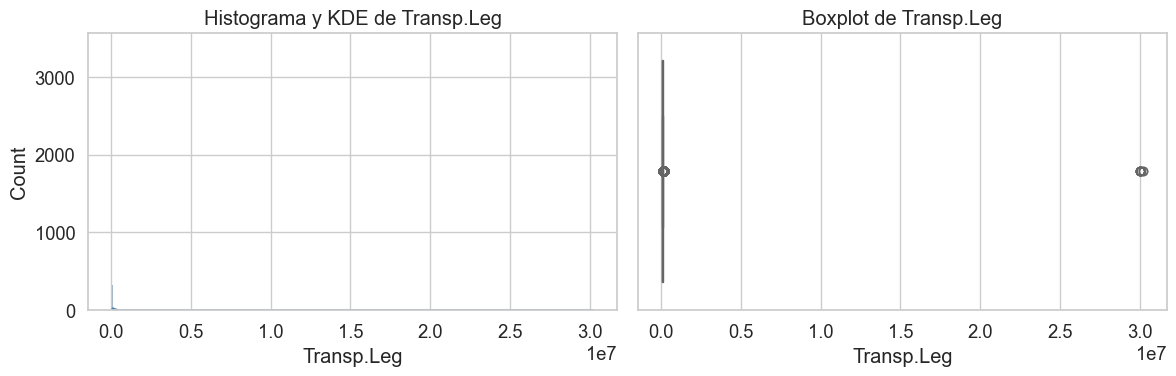

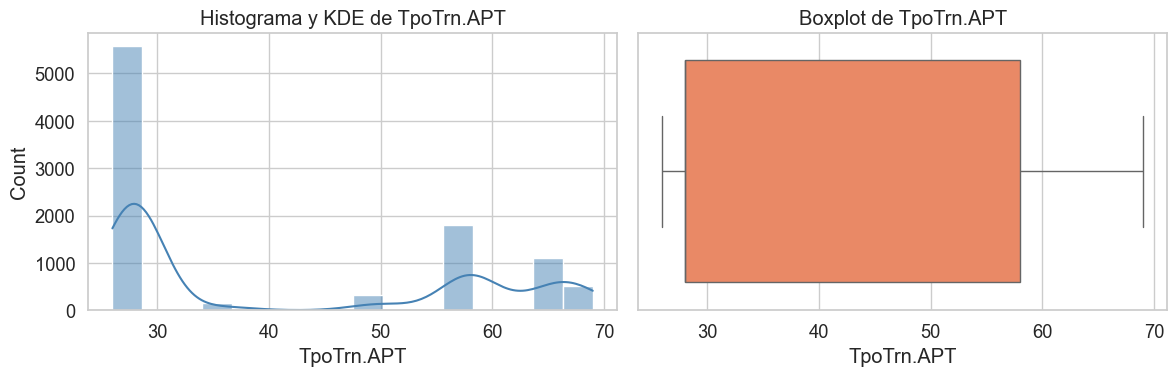

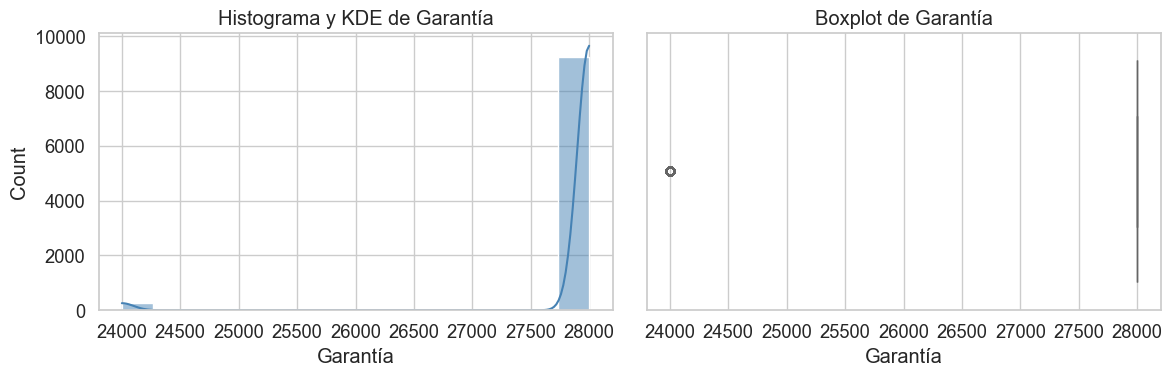

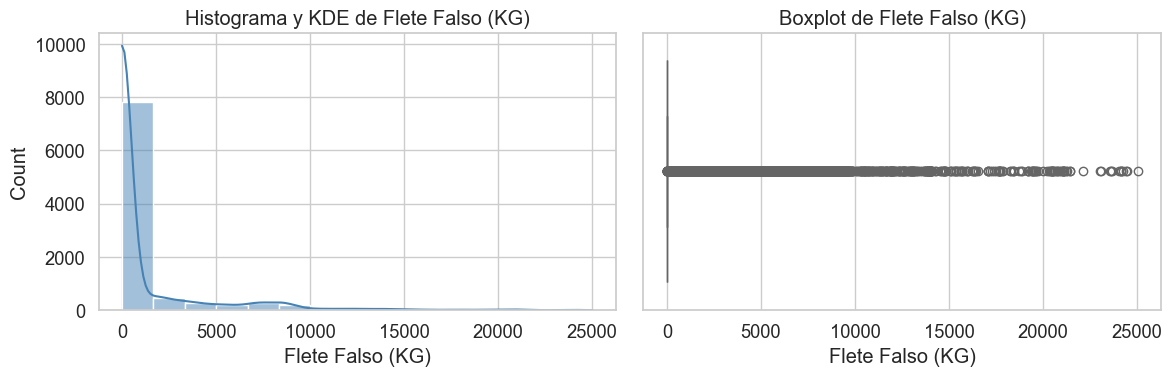

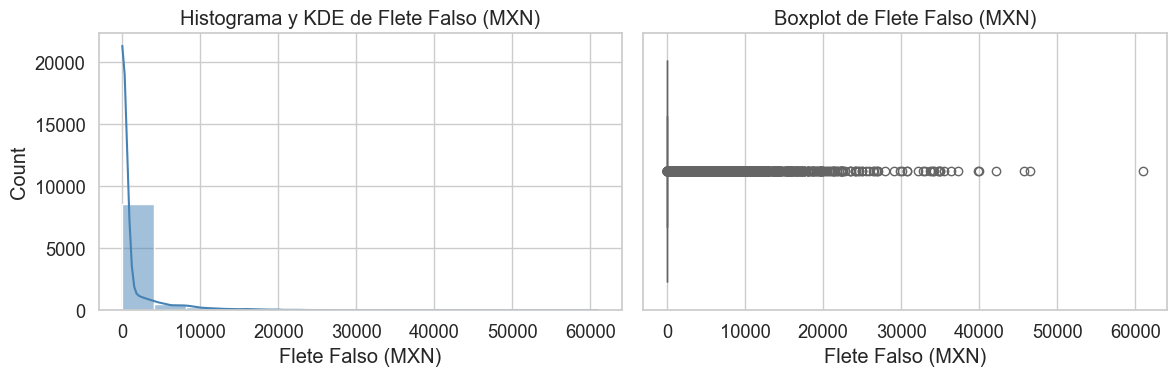

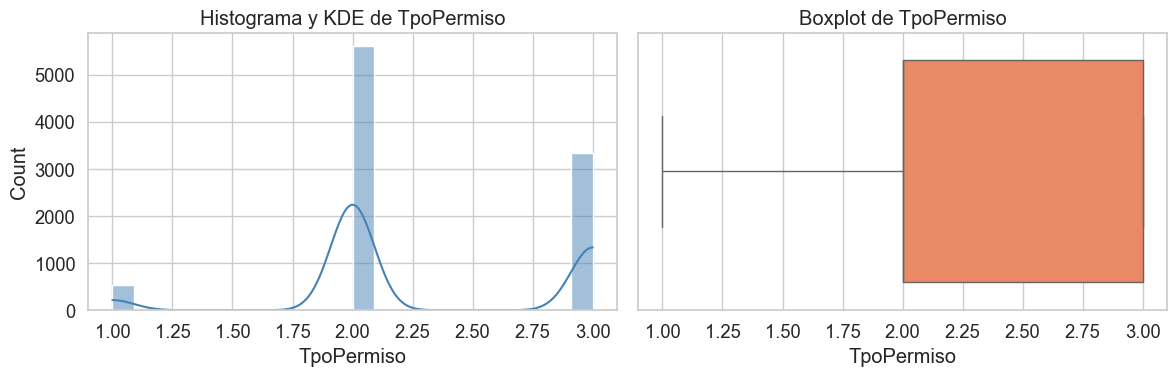

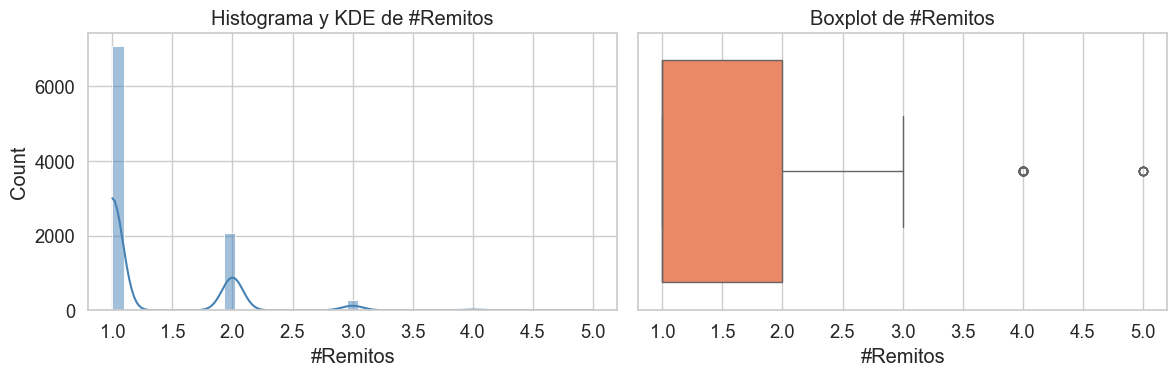

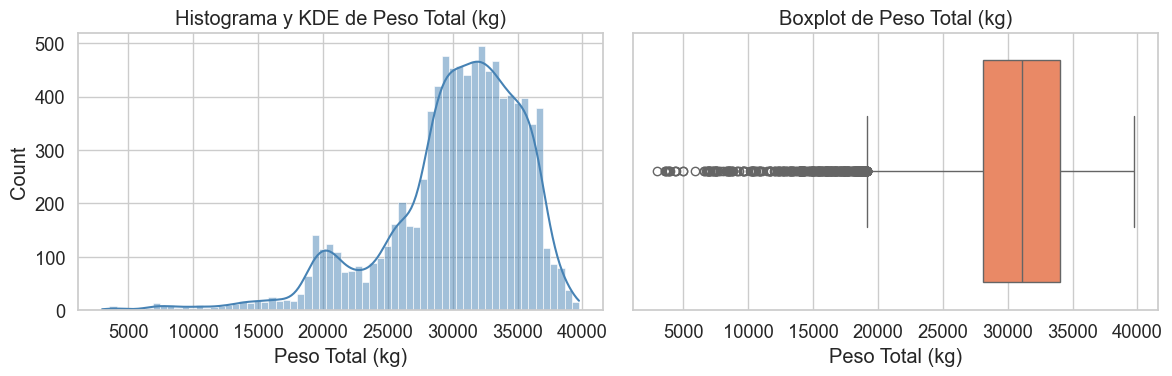

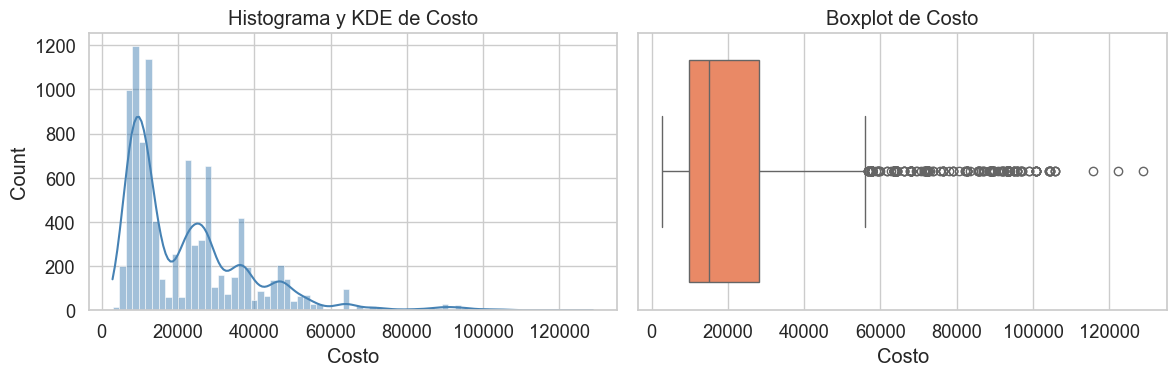

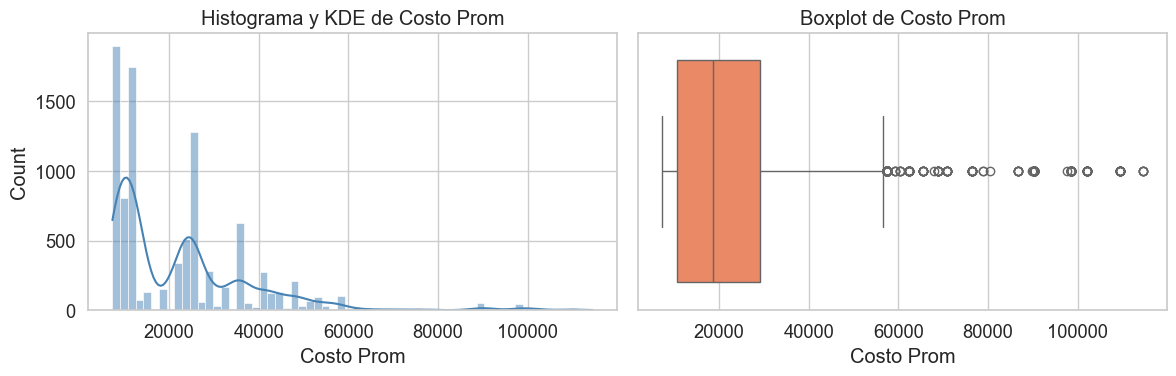

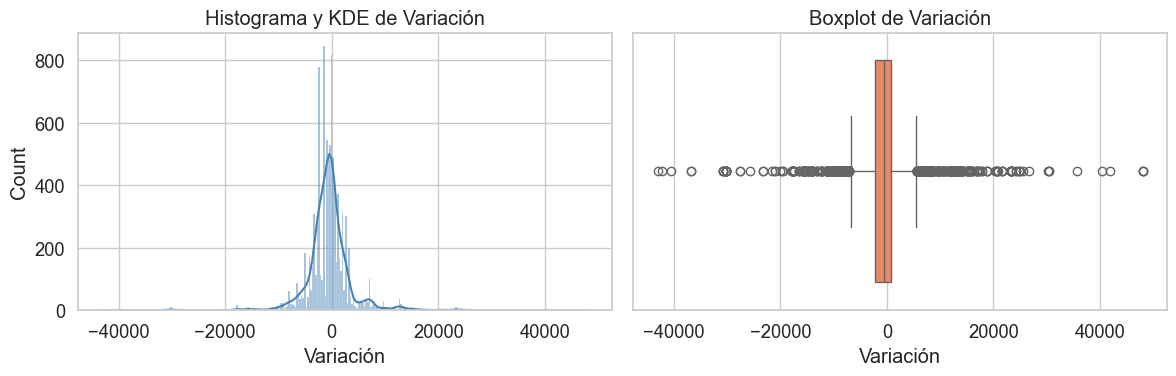

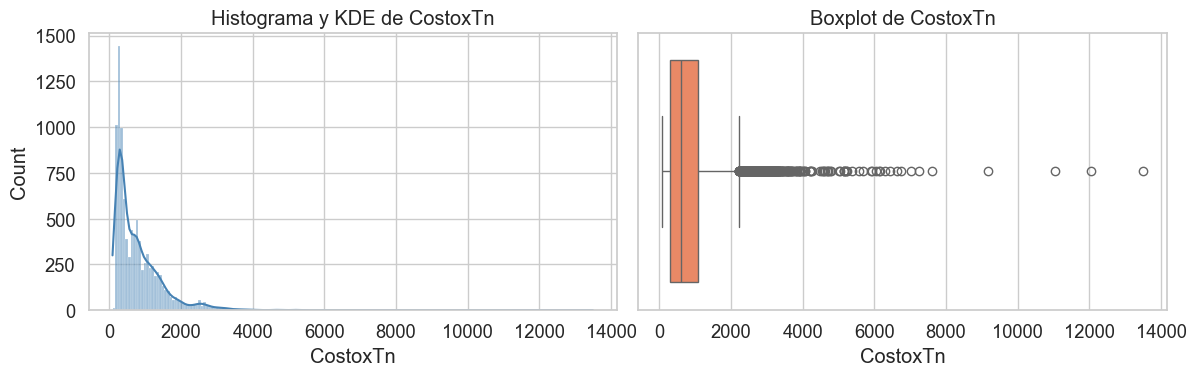

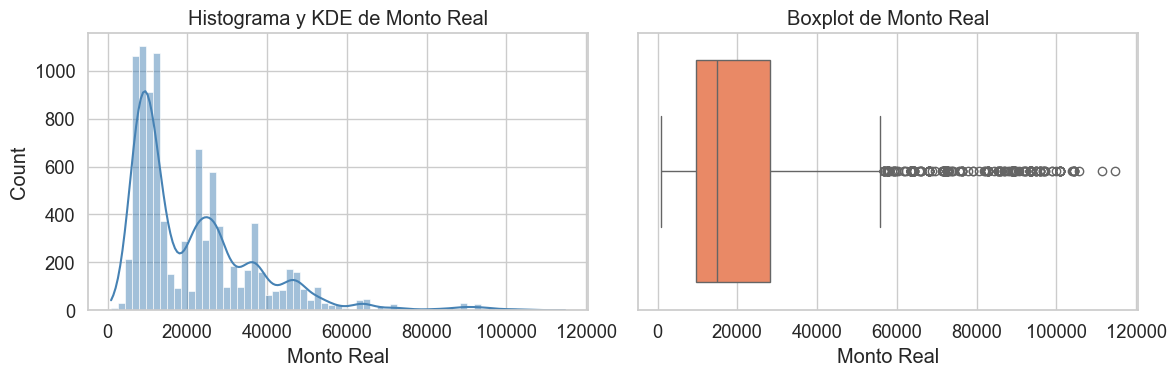

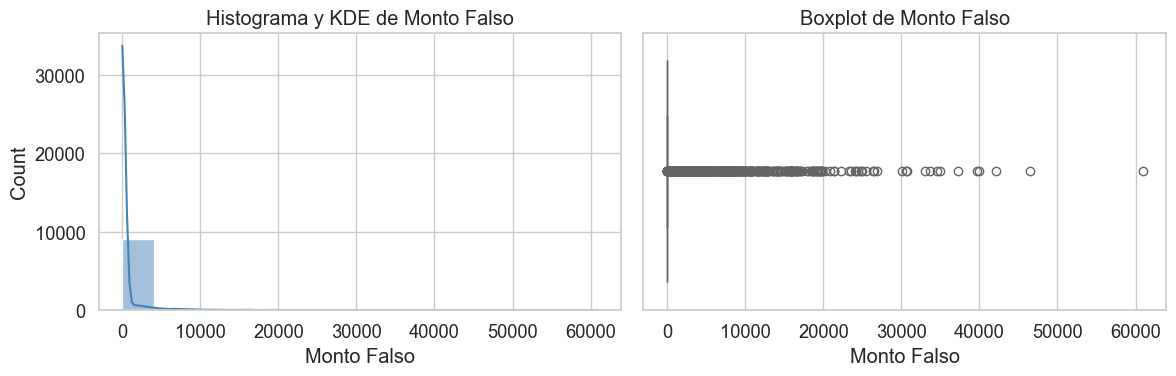

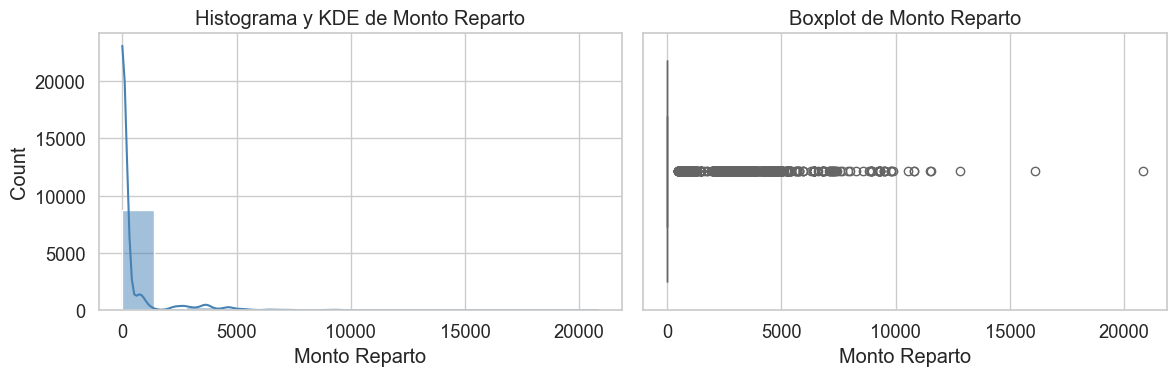

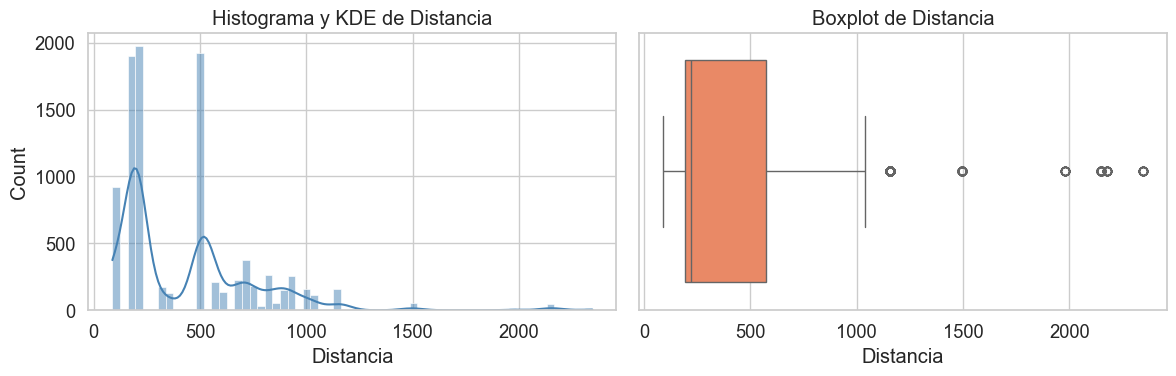

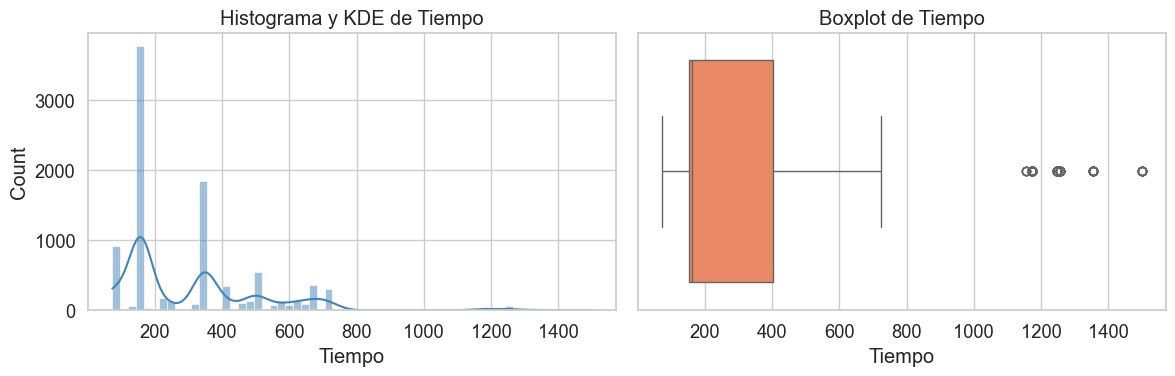

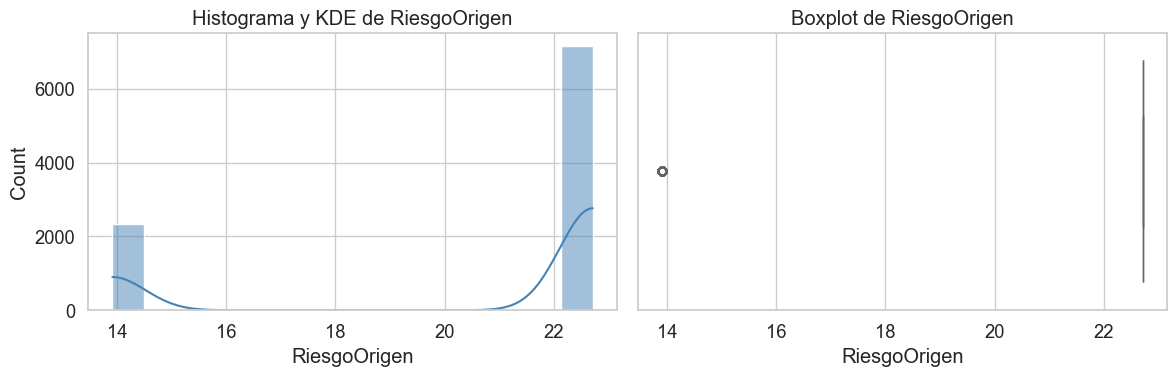

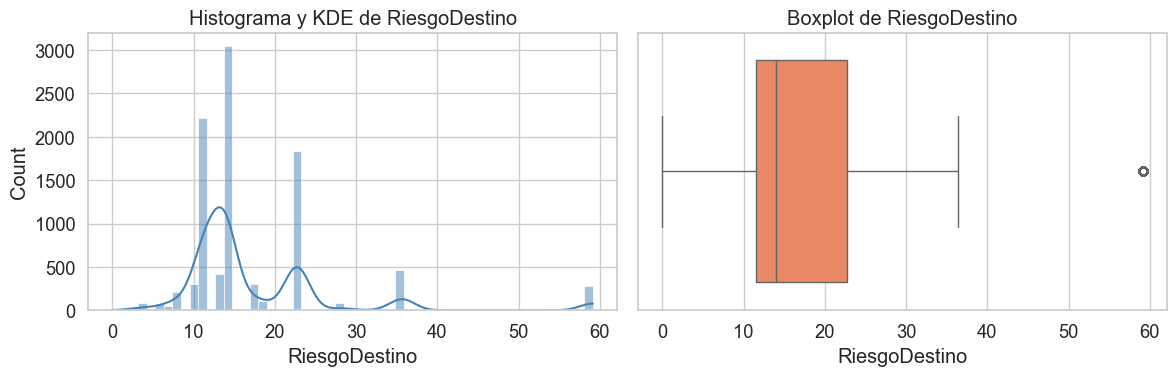

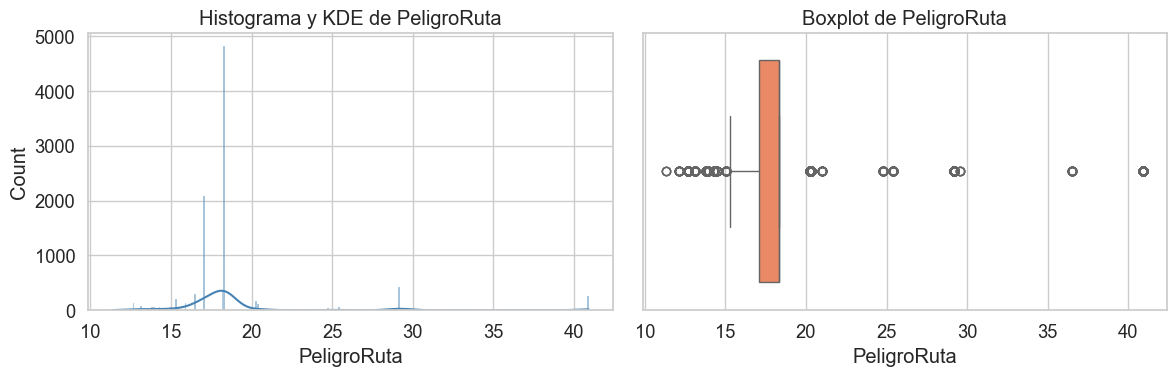

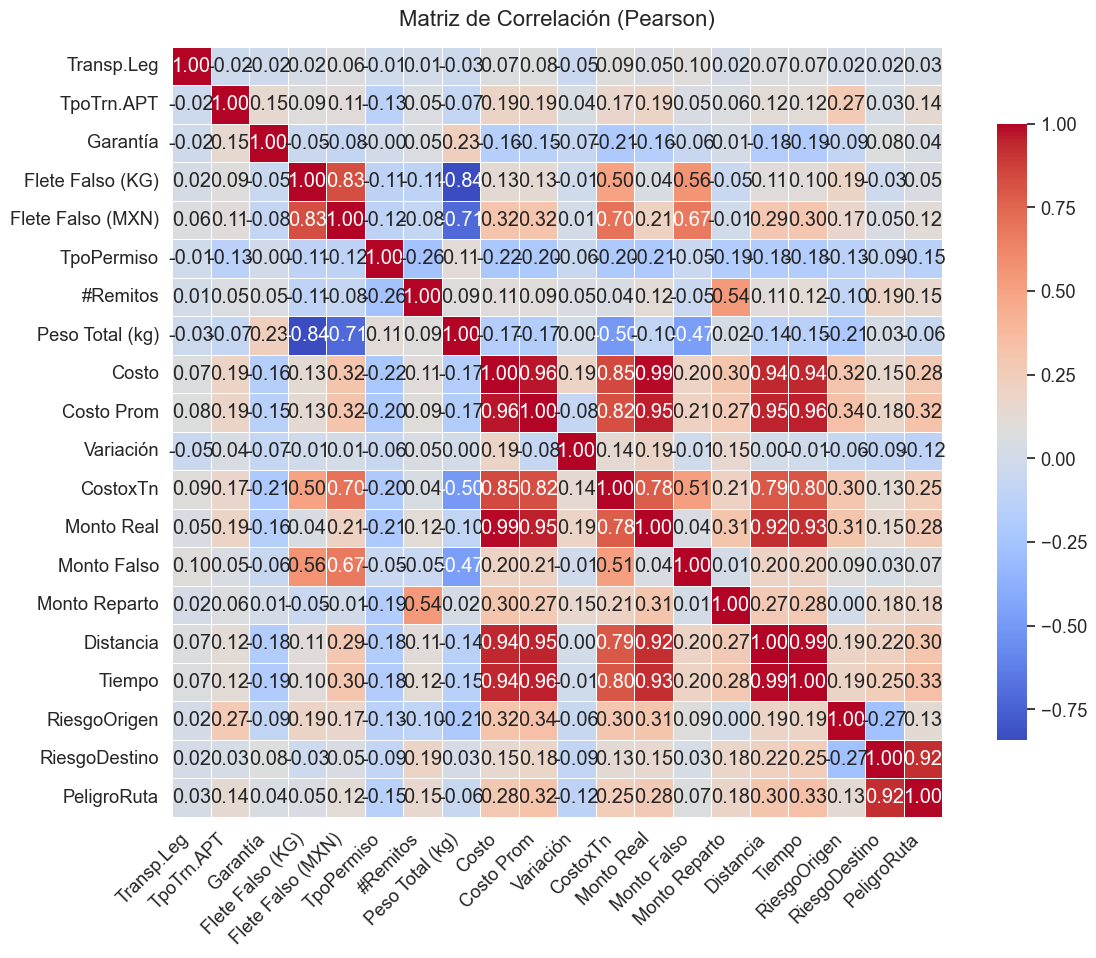

Correlación Pearson:
                    Transp.Leg  TpoTrn.APT  Garantía  Flete Falso (KG)  \
Transp.Leg               1.00       -0.02     -0.02              0.02   
TpoTrn.APT              -0.02        1.00      0.15              0.09   
Garantía                -0.02        0.15      1.00             -0.05   
Flete Falso (KG)         0.02        0.09     -0.05              1.00   
Flete Falso (MXN)        0.06        0.11     -0.08              0.83   
TpoPermiso              -0.01       -0.13     -0.00             -0.12   
#Remitos                 0.01        0.05      0.05             -0.11   
Peso Total (kg)         -0.03       -0.07      0.23             -0.84   
Costo                    0.07        0.19     -0.17              0.13   
Costo Prom               0.08        0.19     -0.15              0.13   
Variación               -0.05        0.04     -0.07             -0.01   
CostoxTn                 0.09        0.17     -0.21              0.50   
Monto Real               0.05

,Media,Mediana,Moda,Varianza,Desviación Std,Coef. Variación (%),Mínimo,Máximo,Rango,Asimetría,Curtosis,Sesgo (z),Sesgo Significativo,p Shapiro,p D’Agostino,p Kolmogorov–Smirnov,Normal (α=0.05),p-valor,Outliers (IQR)
Transp.Leg,144341.84,103079.00,103079.00,943007548029.17,971085.76,672.77,100128.00,30166370.00,30066242.00,30.75,943.95,499.26,True,0.00,0.00,0.00,False,NaN,2041.00
TpoTrn.APT,41.13,28.00,28.00,270.96,16.46,40.02,26.00,69.00,43.00,0.54,-1.56,8.74,True,0.00,0.00,0.00,False,NaN,0.00
Garantía,27895.91,28000.00,28000.00,405559.10,636.84,2.28,24000.00,28000.00,4000.00,-5.96,33.47,-96.70,True,0.00,0.00,0.00,False,NaN,247.00
Flete Falso (KG),1216.46,0.00,0.00,9927709.20,3150.83,259.02,0.00,25030.00,25030.00,3.46,13.97,56.12,True,0.00,0.00,0.00,False,NaN,2224.00
Flete Falso (MXN),1207.29,0.00,0.00,13326715.87,3650.58,302.38,0.00,60961.66,60961.66,5.13,37.67,83.38,True,0.00,0.00,0.00,False,NaN,2224.00
TpoPermiso,2.29,2.00,2.00,0.32,0.57,24.73,1.00,3.00,2.00,-0.09,-0.57,-1.39,False,0.00,0.00,0.00,False,NaN,0.00
#Remitos,1.29,1.00,1.00,0.30,0.55,42.32,1.00,5.00,4.00,1.97,4.40,31.96,True,0.00,0.00,0.00,False,NaN,44.00
Peso Total (kg),30181.88,31117.50,31700.00,29088396.65,5393.37,17.87,2970.00,39737.00,36767.00,-1.28,2.27,-20.71,True,0.00,0.00,0.00,False,NaN,361.00
Costo,22080.70,15000.00,7000.00,270471037.64,16446.00,74.48,2813.14,128794.32,125981.18,1.69,3.90,27.51,True,0.00,0.00,0.00,False,NaN,329.00
Costo Prom,22617.85,18706.04,12319.64,262547093.03,16203.31,71.64,7355.81,114524.33,107168.52,1.94,5.50,31.42,True,0.00,0.00,0.00,False,NaN,313.00


In [10]:
resumen = analisis_estadistico_avanzado(ternium, plot=True, figsize_corr=(14,10))
resumen


In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import entropy

def analisis_estadistico_categorico(df, plot=True):
    """
    Realiza un análisis estadístico detallado de las variables NO numéricas de un DataFrame.
    
    Incluye:
    - Conteos de categorías y porcentajes
    - Cardinalidad y valores únicos
    - Entropía (diversidad de categorías)
    - Moda y frecuencia
    - Análisis de fechas y horas (año, mes, día, hora, día_semana)
    - Detección de valores faltantes
    - Visualizaciones opcionales
    
    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame con variables categóricas o de texto.
    plot : bool, optional
        Si es True, genera gráficos automáticos de frecuencias y tendencias temporales.

    Retorna
    -------
    resumen : pd.DataFrame
        Tabla con resumen estadístico de las columnas no numéricas.
    """

    resumen = []
    df_obj = df.select_dtypes(exclude=[np.number])

    for col in df_obj.columns:
        serie = df_obj[col].dropna()

        info = {
            'Variable': col,
            'Tipo': str(df_obj[col].dtype),
            'Valores Únicos': serie.nunique(),
            'Total Nulos': df_obj[col].isna().sum(),
            'Porcentaje Nulos (%)': (df_obj[col].isna().mean() * 100).round(2),
        }

        # Intentar interpretar como fecha
        es_fecha = False
        try:
            convertida = pd.to_datetime(serie, errors='raise', infer_datetime_format=True)
            es_fecha = True
        except:
            pass

        if es_fecha:
            info['Tipo Detectado'] = 'Fecha/Hora'
            info['Fecha mínima'] = convertida.min()
            info['Fecha máxima'] = convertida.max()
            info['Rango temporal (días)'] = (convertida.max() - convertida.min()).days
            info['Años únicos'] = convertida.dt.year.nunique()
            info['Meses únicos'] = convertida.dt.month.nunique()
            info['Días únicos'] = convertida.dt.day.nunique()
            info['Horas únicas'] = convertida.dt.hour.nunique()
            info['Moda Año'] = convertida.dt.year.mode()[0] if not convertida.dt.year.mode().empty else np.nan

            if plot:
                plt.figure(figsize=(10, 4))
                convertida.value_counts().sort_index().plot()
                plt.title(f"Evolución temporal de {col}")
                plt.xlabel("Fecha")
                plt.ylabel("Frecuencia")
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.show()

        else:
            # Categórica o texto
            info['Tipo Detectado'] = 'Categórica'
            info['Moda'] = serie.mode()[0] if not serie.mode().empty else np.nan
            info['Frecuencia Moda'] = serie.value_counts().iloc[0]
            info['Porcentaje Moda (%)'] = (serie.value_counts(normalize=True).iloc[0] * 100).round(2)
            info['Entropía (bits)'] = round(entropy(serie.value_counts(normalize=True), base=2), 4)

            if plot:
                top_n = min(15, serie.nunique())
                plt.figure(figsize=(10, 4))
                serie.value_counts().head(top_n).plot(kind='bar', color='cornflowerblue', edgecolor='k')
                plt.title(f"Frecuencia de categorías en {col} (Top {top_n})")
                plt.ylabel("Frecuencia")
                plt.xlabel(col)
                plt.xticks(rotation=45, ha='right')
                plt.tight_layout()
                plt.show()

        resumen.append(info)

    resumen_df = pd.DataFrame(resumen)
    return resumen_df


C:\Users\Admin\AppData\Local\Temp\ipykernel_17724\3304127972.py:50: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  convertida = pd.to_datetime(serie, errors='raise', infer_datetime_format=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_17724\3304127972.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  convertida = pd.to_datetime(serie, errors='raise', infer_datetime_format=True)


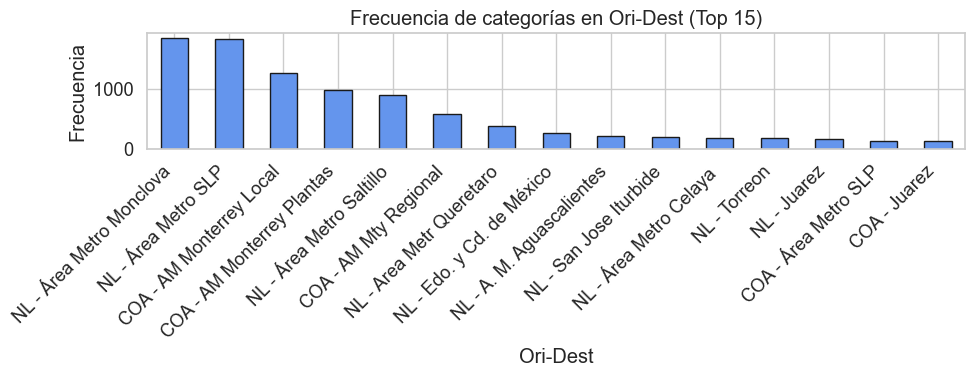

C:\Users\Admin\AppData\Local\Temp\ipykernel_17724\3304127972.py:50: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  convertida = pd.to_datetime(serie, errors='raise', infer_datetime_format=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_17724\3304127972.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  convertida = pd.to_datetime(serie, errors='raise', infer_datetime_format=True)


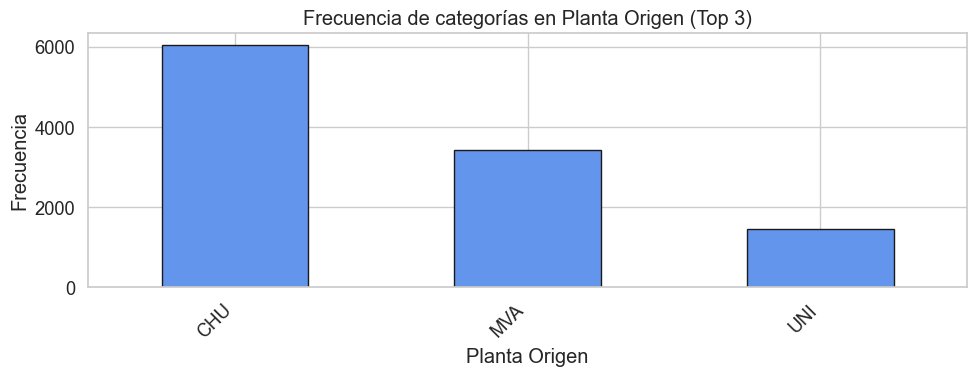

C:\Users\Admin\AppData\Local\Temp\ipykernel_17724\3304127972.py:50: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  convertida = pd.to_datetime(serie, errors='raise', infer_datetime_format=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_17724\3304127972.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  convertida = pd.to_datetime(serie, errors='raise', infer_datetime_format=True)


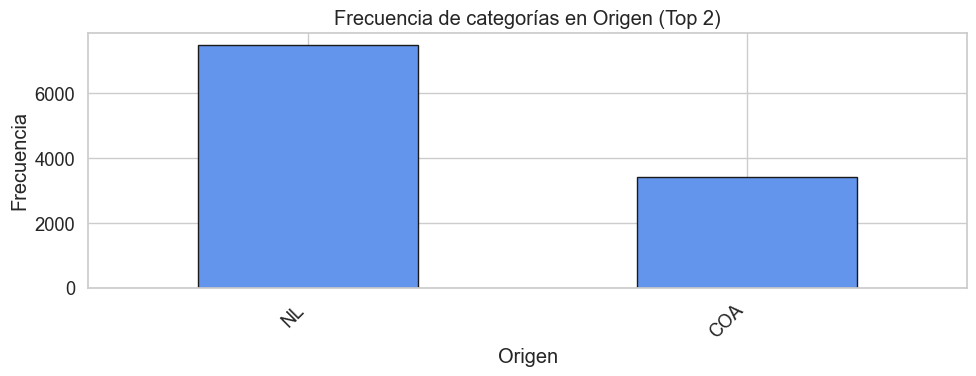

C:\Users\Admin\AppData\Local\Temp\ipykernel_17724\3304127972.py:50: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  convertida = pd.to_datetime(serie, errors='raise', infer_datetime_format=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_17724\3304127972.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  convertida = pd.to_datetime(serie, errors='raise', infer_datetime_format=True)


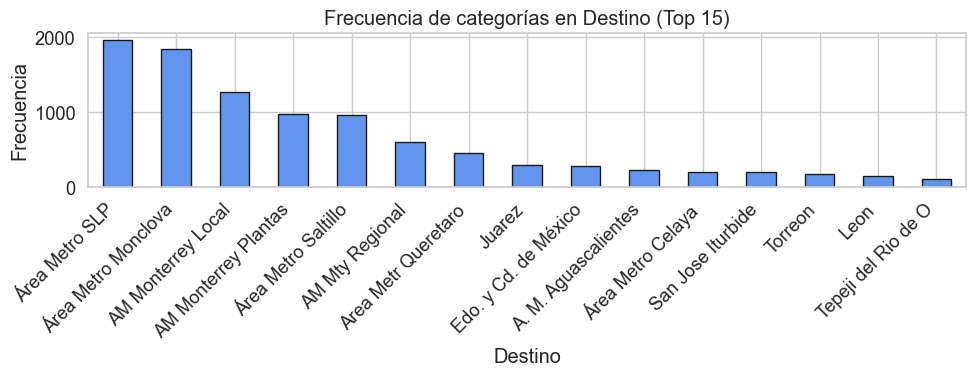

C:\Users\Admin\AppData\Local\Temp\ipykernel_17724\3304127972.py:50: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  convertida = pd.to_datetime(serie, errors='raise', infer_datetime_format=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_17724\3304127972.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  convertida = pd.to_datetime(serie, errors='raise', infer_datetime_format=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_17724\3304127972.py:92: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


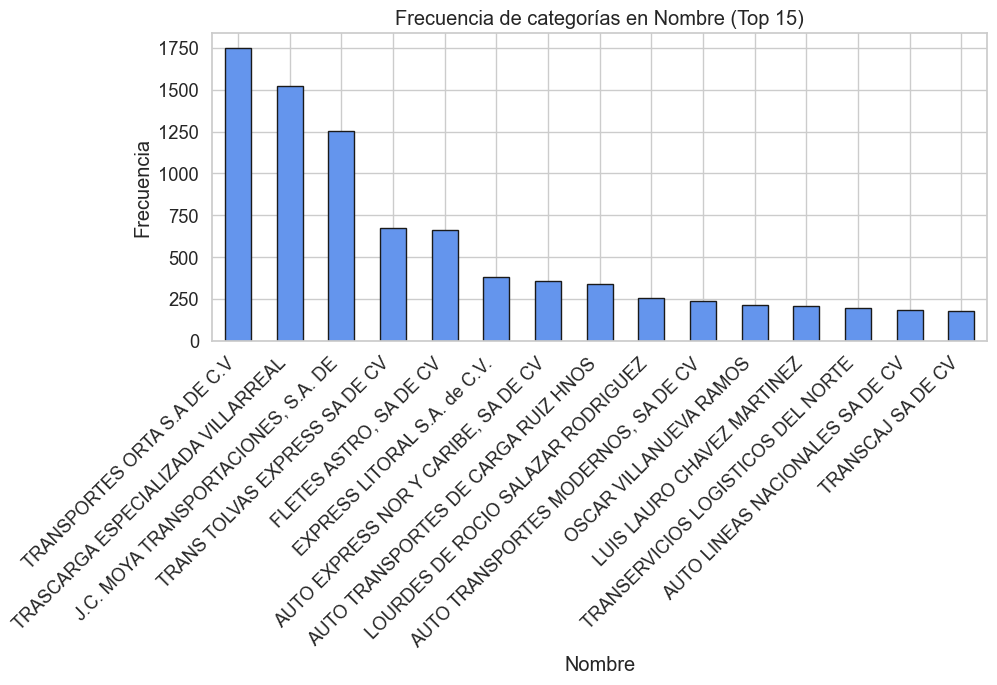

C:\Users\Admin\AppData\Local\Temp\ipykernel_17724\3304127972.py:50: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  convertida = pd.to_datetime(serie, errors='raise', infer_datetime_format=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_17724\3304127972.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  convertida = pd.to_datetime(serie, errors='raise', infer_datetime_format=True)


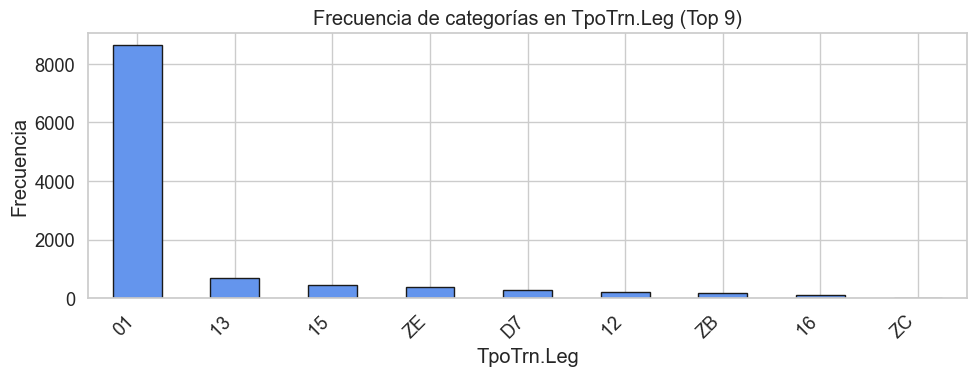

C:\Users\Admin\AppData\Local\Temp\ipykernel_17724\3304127972.py:50: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  convertida = pd.to_datetime(serie, errors='raise', infer_datetime_format=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_17724\3304127972.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  convertida = pd.to_datetime(serie, errors='raise', infer_datetime_format=True)


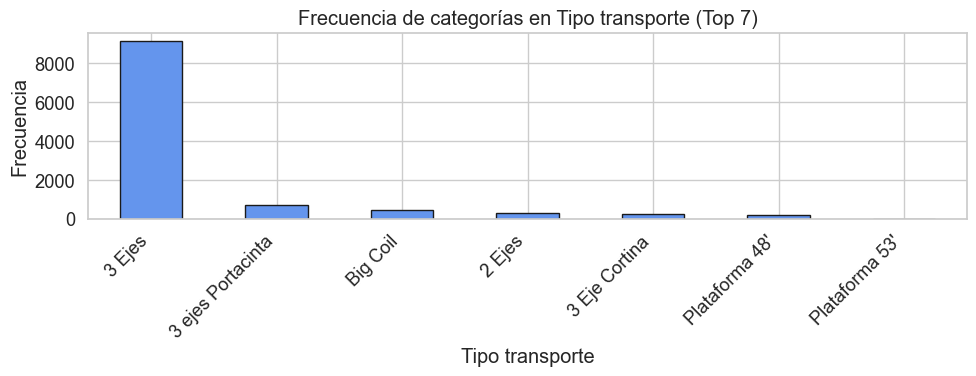

C:\Users\Admin\AppData\Local\Temp\ipykernel_17724\3304127972.py:50: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  convertida = pd.to_datetime(serie, errors='raise', infer_datetime_format=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_17724\3304127972.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  convertida = pd.to_datetime(serie, errors='raise', infer_datetime_format=True)


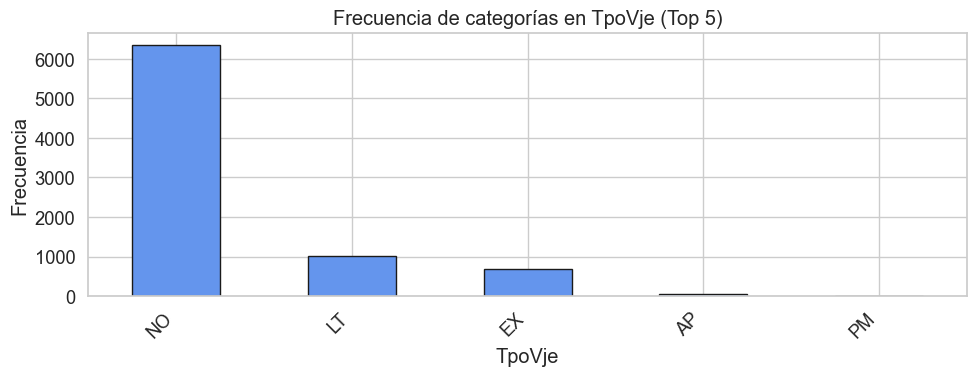

C:\Users\Admin\AppData\Local\Temp\ipykernel_17724\3304127972.py:50: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  convertida = pd.to_datetime(serie, errors='raise', infer_datetime_format=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_17724\3304127972.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  convertida = pd.to_datetime(serie, errors='raise', infer_datetime_format=True)


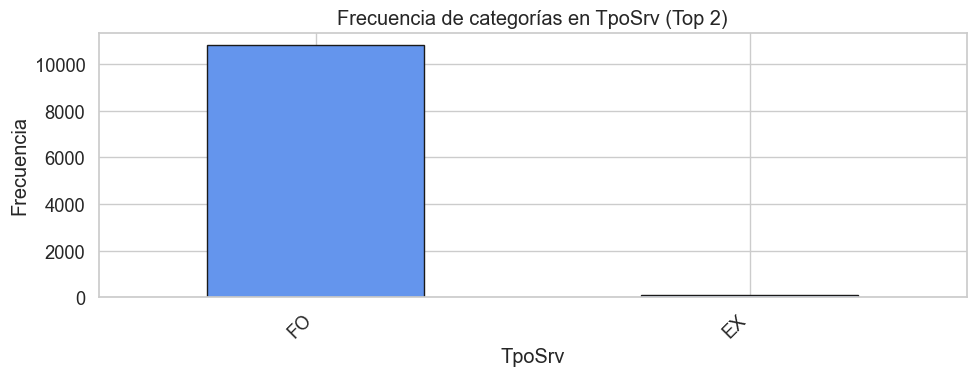

C:\Users\Admin\AppData\Local\Temp\ipykernel_17724\3304127972.py:50: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  convertida = pd.to_datetime(serie, errors='raise', infer_datetime_format=True)


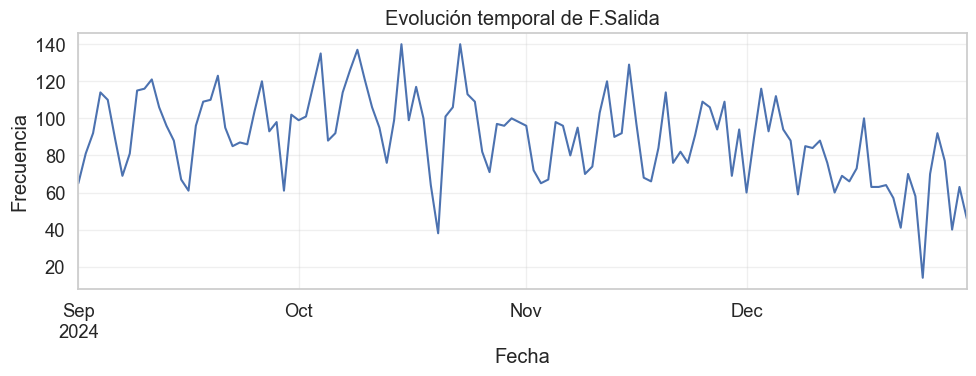

C:\Users\Admin\AppData\Local\Temp\ipykernel_17724\3304127972.py:50: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  convertida = pd.to_datetime(serie, errors='raise', infer_datetime_format=True)


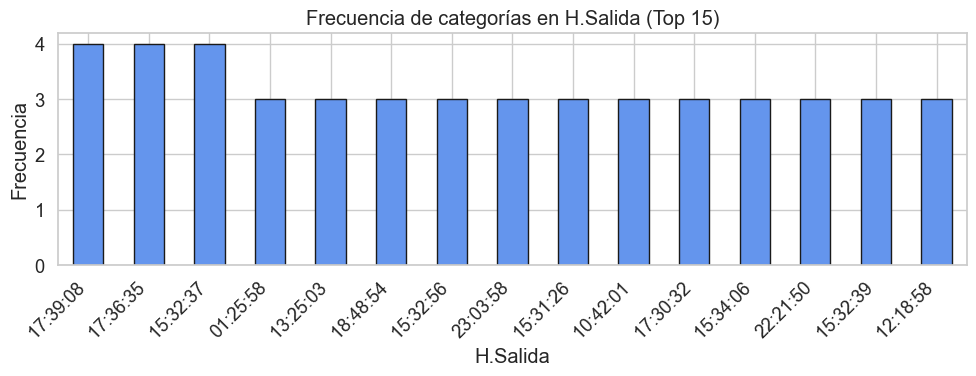

C:\Users\Admin\AppData\Local\Temp\ipykernel_17724\3304127972.py:50: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  convertida = pd.to_datetime(serie, errors='raise', infer_datetime_format=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_17724\3304127972.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  convertida = pd.to_datetime(serie, errors='raise', infer_datetime_format=True)


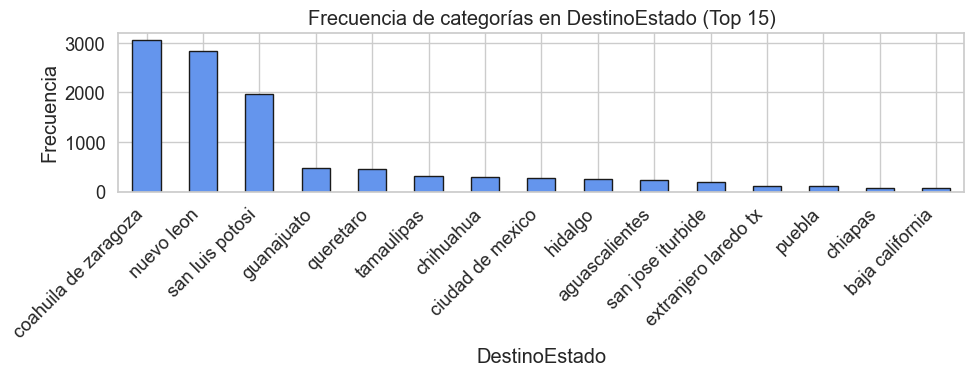

C:\Users\Admin\AppData\Local\Temp\ipykernel_17724\3304127972.py:50: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  convertida = pd.to_datetime(serie, errors='raise', infer_datetime_format=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_17724\3304127972.py:50: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  convertida = pd.to_datetime(serie, errors='raise', infer_datetime_format=True)


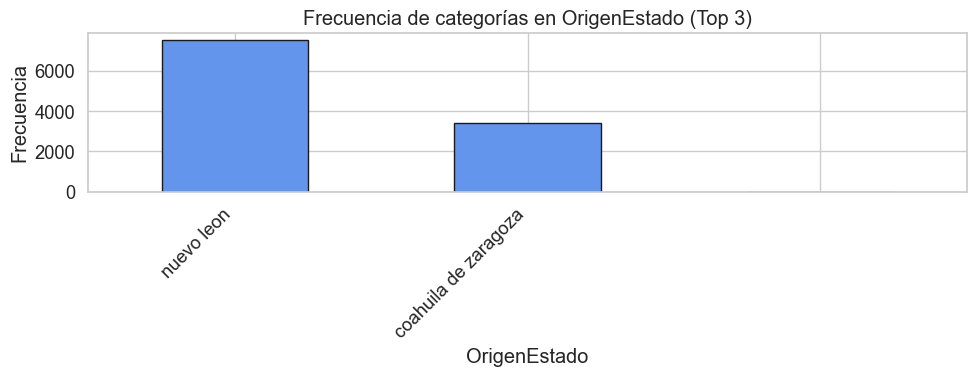

,Variable,Tipo,Valores Únicos,Total Nulos,Porcentaje Nulos (%),Tipo Detectado,Moda,Frecuencia Moda,Porcentaje Moda (%),Entropía (bits),Fecha mínima,Fecha máxima,Rango temporal (días),Años únicos,Meses únicos,Días únicos,Horas únicas,Moda Año
0,Ori-Dest,object,67,1,0.01,Categórica,NL - Área Metro Monclova,1845.00,16.88,4.19,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1,Planta Origen,object,3,1,0.01,Categórica,CHU,6046.00,55.32,1.39,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
2,Origen,object,2,1,0.01,Categórica,NL,7509.00,68.70,0.90,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
3,Destino,object,50,1,0.01,Categórica,Área Metro SLP,1960.00,17.93,3.98,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
4,Nombre,object,81,1,0.01,Categórica,TRANSPORTES ORTA S.A DE C.V,1750.00,16.01,4.61,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
5,TpoTrn.Leg,object,9,1,0.01,Categórica,01,8632.00,78.98,1.29,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
6,Tipo transporte,object,7,1,0.01,Categórica,3 Ejes,9137.00,83.60,1.00,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
7,TpoVje,object,5,2847,26.05,Categórica,NO,6350.00,78.55,0.99,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
8,TpoSrv,object,2,1,0.01,Categórica,FO,10812.00,98.92,0.09,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
9,F.Salida,datetime64[ns],122,1,0.01,Fecha/Hora,NaN,NaN,NaN,NaN,2024-09-01,2024-12-31,121.00,1.00,4.00,31.00,1.00,2024.00


In [12]:
analisis_estadistico_categorico(ternium, plot=True)

### Rutas outliers
Encontramos las rutas que son outliers en 'costo_x_tonelada_prom_x_km' o 'costo_x_tonelada_prom_x_min'.

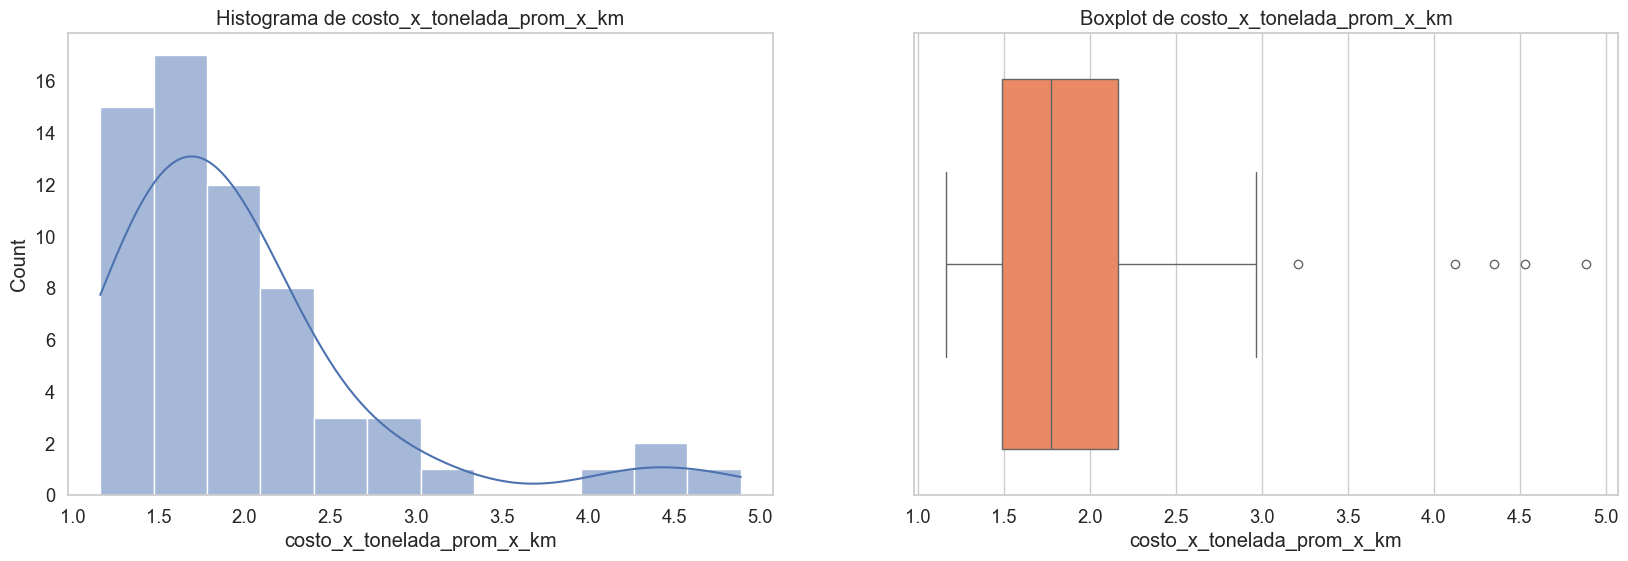

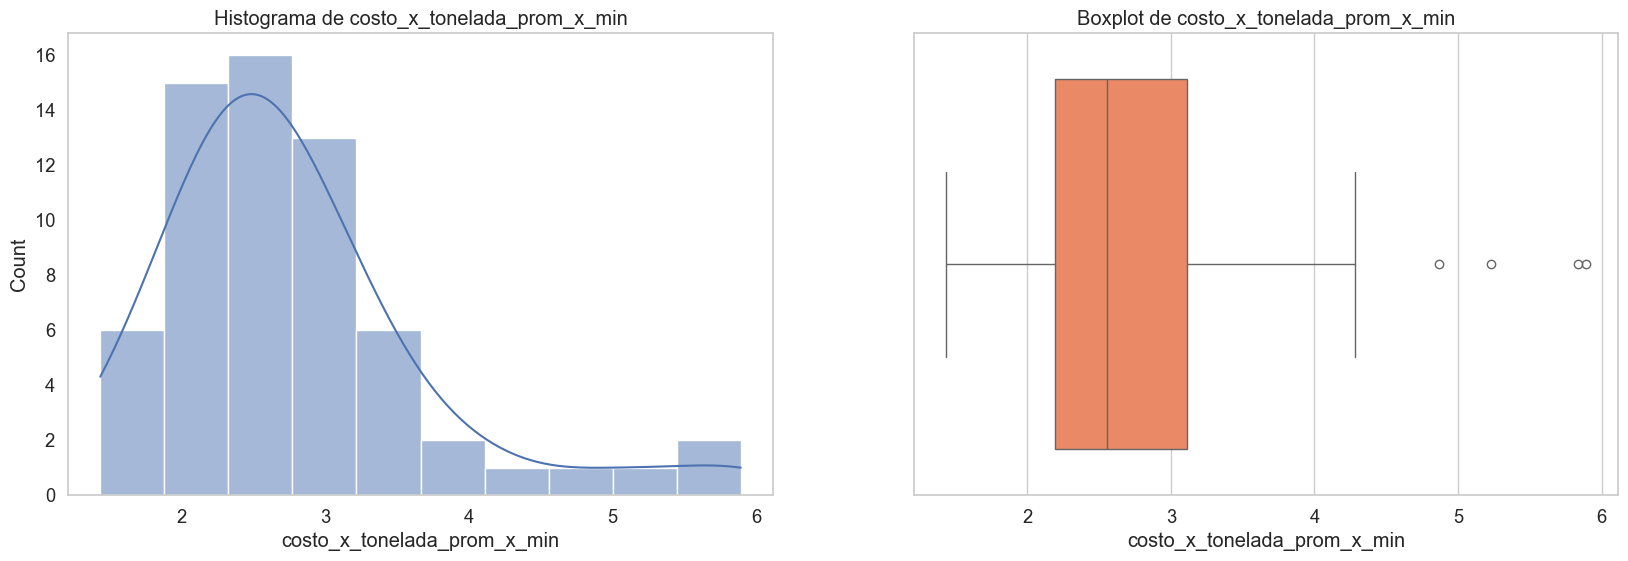

In [13]:
hist_keys = ['costo_x_tonelada_prom_x_km', 'costo_x_tonelada_prom_x_min']
for key in hist_keys:
    fig, ax = plt.subplots(1,2,figsize=(20,6))
    sns.histplot(rutas[key].dropna(), kde=True, ax=ax[0])
    sns.boxplot(x=rutas[key], color='coral', ax=ax[1])
    
    ax[0].set_title(f'Histograma de {key}')
    ax[0].grid()
    
    ax[1].set_title(f'Boxplot de {key}')
    
    plt.show()

Se observan a la dereca de la gráfica unos como 4-5 outliers

In [14]:
"""# La más outlier
bar_keys = ['costo_x_tonelada_prom_x_km', 'costo_x_tonelada_prom_x_min']
for key in bar_keys:
    mean = rutas[key].mean()
    std = rutas[key].std()
    rutas['z_'+key] = (rutas[key] - mean) / std

outliers = rutas[np.abs(rutas['z_'+bar_keys[0]]) > 3]
outliers = outliers[np.abs(outliers['z_'+bar_keys[1]]) > 3]
outliers"""

"# La más outlier\nbar_keys = ['costo_x_tonelada_prom_x_km', 'costo_x_tonelada_prom_x_min']\nfor key in bar_keys:\n    mean = rutas[key].mean()\n    std = rutas[key].std()\n    rutas['z_'+key] = (rutas[key] - mean) / std\n\noutliers = rutas[np.abs(rutas['z_'+bar_keys[0]]) > 3]\noutliers = outliers[np.abs(outliers['z_'+bar_keys[1]]) > 3]\noutliers"

In [15]:
lower = []
upper = []

for key in hist_keys:
    Q1 = rutas[key].quantile(0.25)
    Q3 = rutas[key].quantile(0.75)
    IQR = Q3 - Q1

    lower.append(Q1 - 1.5 * IQR)
    upper.append(Q3 + 1.5 * IQR)

outliers = rutas[((rutas[hist_keys[0]] < lower[0]) | (rutas[hist_keys[0]] > upper[0])) | ((rutas[hist_keys[1]] < lower[1]) | (rutas[hist_keys[1]] > upper[1]))]
outliers.sort_values(by=hist_keys, ascending=False)

,Ori-Dest,Distancia,Tiempo,costo_x_tonelada_prom,costo_x_tonelada_prom_x_km,costo_x_tonelada_prom_x_min
9,NL - Área Metro Saltillo,88.00,73.00,430.05,4.89,5.89
57,"COA - Laredo, TX",263.00,228.00,1191.28,4.53,5.22
23,"NL - Laredo, TX",224.00,167.00,974.34,4.35,5.83
11,NL - Arteaga,93.30,79.00,384.70,4.12,4.87
40,NL - Tetla,895.00,671.00,2872.10,3.21,4.28


Son las rutas más costosas

## Análisis por transportista

Queremos identificar las empresas transportistas más alejadas del promedio de costos. Para ello, calculamos el costo por tonelada por km y el costo por tonelada por tiempo para compararlos entre sí.

In [16]:
ternium['CostoxTnxKm'] = ternium['CostoxTn'] / ternium['Distancia']
ternium['CostoxTnxMin'] = ternium['CostoxTn'] / ternium['Tiempo']

transportistas = pd.DataFrame({
    'Transportista': ternium['Nombre'].unique(),
    'CostoxTnxKm_prom': [ternium[ternium['Nombre'] == t]['CostoxTnxKm'].mean() for t in ternium['Nombre'].unique()],
    'CostoxTnxMin_prom': [ternium[ternium['Nombre'] == t]['CostoxTnxMin'].mean() for t in ternium['Nombre'].unique()],
    '# Pedidos': [ternium[ternium['Nombre'] == t].shape[0] for t in ternium['Nombre'].unique()]
})
transportistas.sort_values(by='# Pedidos', ascending=False)

,Transportista,CostoxTnxKm_prom,CostoxTnxMin_prom,# Pedidos
25,TRANSPORTES ORTA S.A DE C.V,2.68,3.55,1750
7,TRASCARGA ESPECIALIZADA VILLARREAL,1.29,1.60,1522
2,"J.C. MOYA TRANSPORTACIONES, S.A. DE",2.17,2.85,1254
8,TRANS TOLVAS EXPRESS SA DE CV,1.83,2.33,673
30,"FLETES ASTRO, SA DE CV",2.24,3.05,661
...,...,...,...,...
63,EDGAR LEAL PERALES,5.32,6.42,1
73,TRASLADOS Y LOGISTICA ESPECIALIZADA,1.22,1.65,1
74,AUTOTRANSPORTE 4 M,1.08,1.46,1
79,JOSE DE JESUS BERZOSA ALVAREZ,1.99,2.74,1


**Costo por # de pedidos**

Graficamos los costos en función del # de pedidos a ver si hay una tendencia inversamente proporcional.

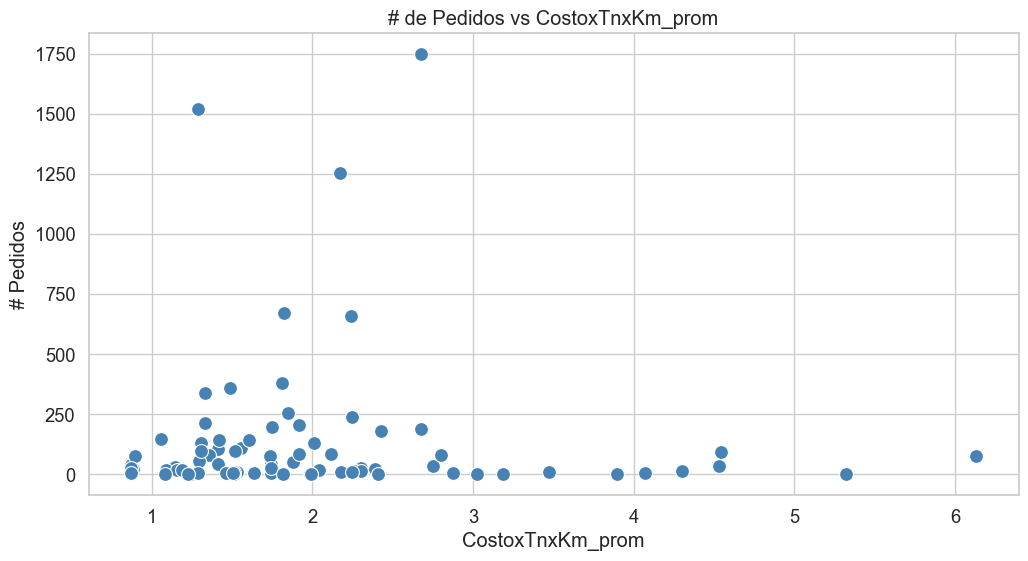

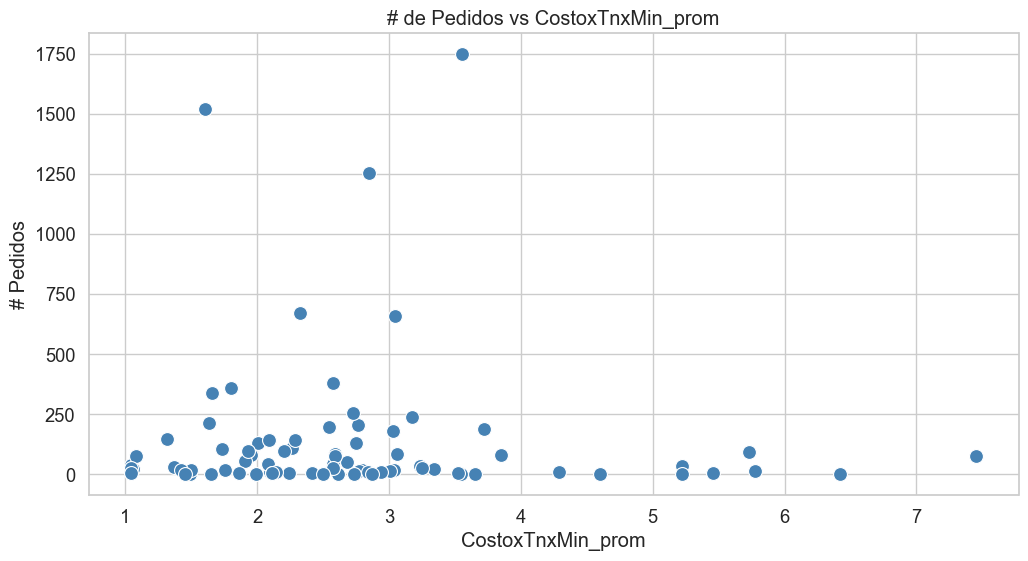

In [17]:
hist_keys = ['CostoxTnxKm_prom', 'CostoxTnxMin_prom']

for key in hist_keys:
    plt.figure(figsize=(12,6))
    sns.scatterplot(data=transportistas, y='# Pedidos', x=key, color='steelblue', s=100)
    plt.title('# de Pedidos vs ' + key)
    plt.show()

No se observa la tendencia esperada.

**Grafiquitas**

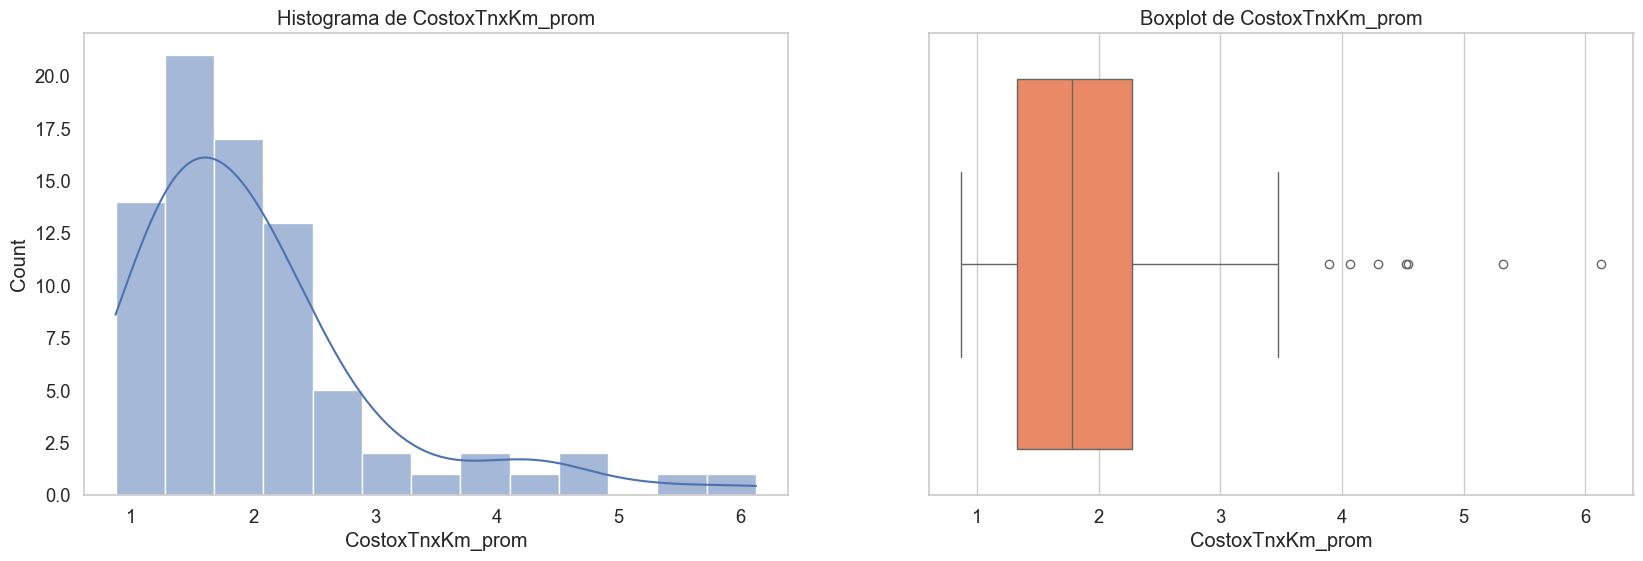

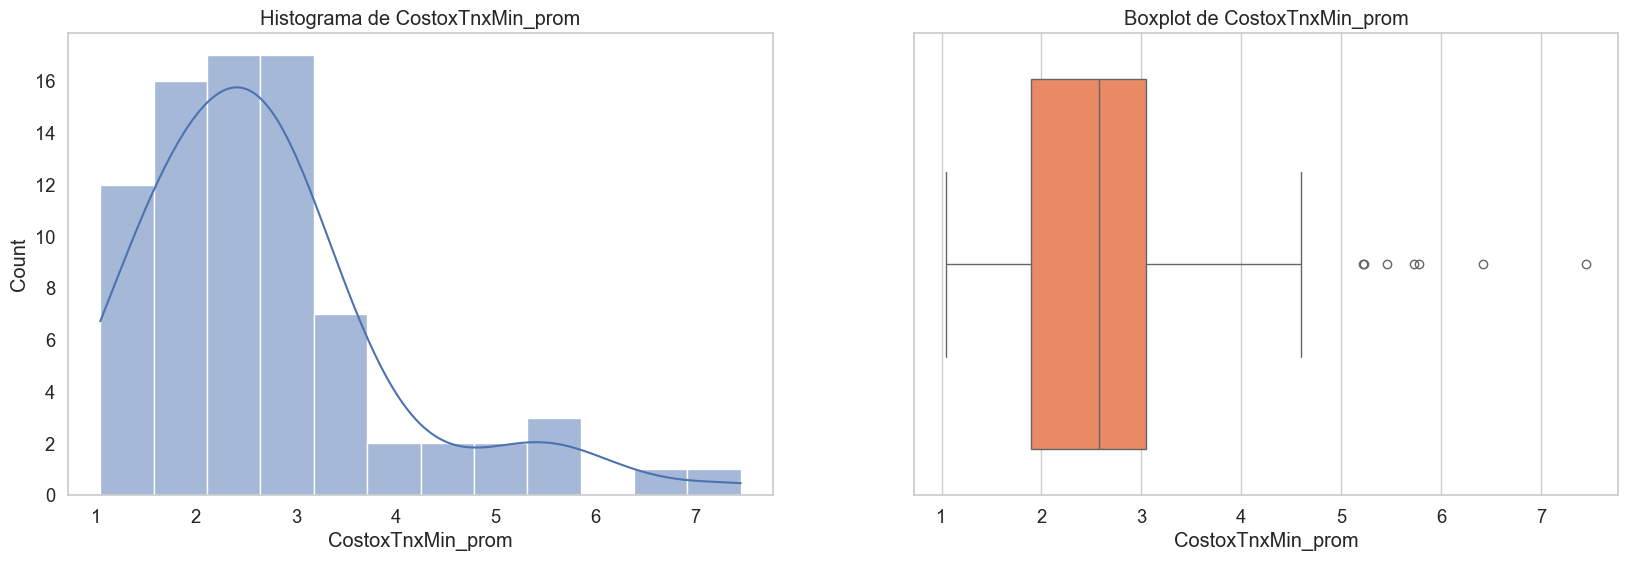

In [18]:
for key in hist_keys:
    fig, ax = plt.subplots(1,2,figsize=(20,6))
    sns.histplot(transportistas[key].dropna(), kde=True, ax=ax[0])
    sns.boxplot(x=transportistas[key], color='coral', ax=ax[1])
    
    ax[0].set_title(f'Histograma de {key}')
    ax[0].grid()
    
    ax[1].set_title(f'Boxplot de {key}')
    
    plt.show()

Unos cuantos outliers

In [19]:
lower = []
upper = []

for key in hist_keys:
    Q1 = transportistas[key].quantile(0.25)
    Q3 = transportistas[key].quantile(0.75)
    IQR = Q3 - Q1

    lower.append(Q1 - 1.5 * IQR)
    upper.append(Q3 + 1.5 * IQR)

outliers = transportistas[((transportistas[hist_keys[0]] < lower[0]) | (transportistas[hist_keys[0]] > upper[0])) | ((transportistas[hist_keys[1]] < lower[1]) | (transportistas[hist_keys[1]] > upper[1]))]
outliers['z_CostoxTnxKm_prom'] = (outliers['CostoxTnxKm_prom'] - transportistas['CostoxTnxKm_prom'].mean()) / transportistas['CostoxTnxKm_prom'].std()
outliers['z_CostoxTnxMin_prom'] = (outliers['CostoxTnxMin_prom'] - transportistas['CostoxTnxMin_prom'].mean()) / transportistas['CostoxTnxMin_prom'].std()
outliers.sort_values(by=['z_CostoxTnxKm_prom', 'z_CostoxTnxMin_prom'], ascending=False)

C:\Users\Admin\AppData\Local\Temp\ipykernel_17724\1460645752.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers['z_CostoxTnxKm_prom'] = (outliers['CostoxTnxKm_prom'] - transportistas['CostoxTnxKm_prom'].mean()) / transportistas['CostoxTnxKm_prom'].std()
C:\Users\Admin\AppData\Local\Temp\ipykernel_17724\1460645752.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers['z_CostoxTnxMin_prom'] = (outliers['CostoxTnxMin_prom'] - transportistas['CostoxTnxMin_prom'].mean()) / transportistas['Cost

,Transportista,CostoxTnxKm_prom,CostoxTnxMin_prom,# Pedidos,z_CostoxTnxKm_prom,z_CostoxTnxMin_prom
55,AUTO LINEAS BELEN SA DE CV,6.13,7.45,76,3.99,3.72
63,EDGAR LEAL PERALES,5.32,6.42,1,3.21,2.91
20,"AUTO FLETES TRT, S.A. DE C.V.",4.54,5.73,95,2.45,2.37
28,"SUPER EXPRESS LINARES, S.A. DE C.V.",4.53,5.22,37,2.43,1.97
44,PORTEADORES UNIDOS DE MONCLOVA SA D,4.30,5.78,14,2.21,2.41
78,SMART FLETES SA DE CV,4.07,5.46,5,1.99,2.16
77,YOLANDA CAROLINA DE JESUS CASTAÑEDA,3.89,5.22,2,1.82,1.97


Son los transportistas más costosos

## Comparación por meses
Dado que el objetivo es conocer la razón por la cual suceden variaciones significativas en costos de transporte entre diferentes períodos. Se comparan los datos por mes.

In [20]:
df = ternium[['Ori-Dest','Nombre','Tipo transporte','F.Salida','#Remitos','Peso Total (kg)','Costo','CostoxTn','Monto Real','Monto Falso','Monto Reparto','Distancia','Tiempo','CostoxTnxKm','CostoxTnxMin']] # los features que podrían interesar
df['F.Salida'] = pd.to_datetime(df['F.Salida'], format='%d/%m/%Y')

C:\Users\Admin\AppData\Local\Temp\ipykernel_17724\2704716242.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['F.Salida'] = pd.to_datetime(df['F.Salida'], format='%d/%m/%Y')


In [21]:
dfs_por_mes = {mes: grupo for mes, grupo in df.groupby(df['F.Salida'].dt.month)} #keys son el número del mes (9,10,11,12)
meses = pd.DataFrame()
meses_str = ['Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
for i in range(9,13):
    line = {'Viajes': dfs_por_mes[i].shape[0],
            'Costo': dfs_por_mes[i]['Costo'].sum(),
            'Peso Total (Tn)': dfs_por_mes[i]['Peso Total (kg)'].sum()/1000,
            'Distancia Total (km)': dfs_por_mes[i]['Distancia'].sum(),
            'Dstancia_prom': dfs_por_mes[i]['Distancia'].mean(),
            'CostoxTnxKm_prom': dfs_por_mes[i]['CostoxTnxKm'].mean(),
            'Tiempo Total (min)': dfs_por_mes[i]['Tiempo'].sum(),
            'Tiempo_prom': dfs_por_mes[i]['Tiempo'].mean(),
            'CostoxTnxMin_prom': dfs_por_mes[i]['CostoxTnxMin'].mean()}
    meses = pd.concat([meses, pd.DataFrame(line, index=[i])])
meses.set_index(pd.Index(meses_str), inplace=True)
meses.T

,Septiembre,Octubre,Noviembre,Diciembre
Viajes,2840.00,3178.00,2682.00,2230.00
Costo,59855022.16,68306472.43,58540169.02,43591811.05
Peso Total (Tn),85496.42,96088.45,81069.35,67621.82
Distancia Total (km),1170371.80,1326203.10,1153962.70,890383.20
Dstancia_prom,413.71,417.44,430.26,401.62
CostoxTnxKm_prom,1.99,1.99,1.98,1.89
Tiempo Total (min),837754.00,951544.00,817657.00,635229.00
Tiempo_prom,296.13,299.51,304.87,286.53
CostoxTnxMin_prom,2.65,2.65,2.64,2.51


Se puede evidenciar que pese a que los costos totales por mes si cambian significativamente, el costo por tonelada por Km ó minuto son casi iguales a exepción de diciembre. Por ejemplo, comparado con Septirmbre, Octubre tuvo mayores costos, pero se debió moyormente a una mayor cantidad de viajes. De igual forma, Noviembre tuvo u costo neto similar a Septiembre, aunque fueron menos viajes, la distancia promedio por viaje fue mayor, compensando el total. Futuros análisis más a detalle podrían resolver la diferencia presentada en el mes de Diciembre

In [22]:
ternium

,Ori-Dest,Planta Origen,Origen,Destino,Transp.Leg,Nombre,TpoTrn.APT,TpoTrn.Leg,Tipo transporte,Garantía,...,Monto Reparto,Distancia,Tiempo,DestinoEstado,OrigenEstado,RiesgoOrigen,RiesgoDestino,PeligroRuta,CostoxTnxKm,CostoxTnxMin
0,COA - A. M. Aguascalientes,MVA,COA,A. M. Aguascalientes,100349.00,TRANSPORTES DE ACERO SA DE CV,28.00,01,3 Ejes,28000.00,...,2675.41,688.00,485.00,aguascalientes,coahuila de zaragoza,13.92,7.86,10.89,1.21,1.71
1,COA - A. M. Aguascalientes,MVA,COA,A. M. Aguascalientes,106207.00,AUTO LINEAS LARROC S.A. DE C.V.,28.00,01,3 Ejes,28000.00,...,0.00,688.00,485.00,aguascalientes,coahuila de zaragoza,13.92,7.86,10.89,1.41,2.00
2,COA - A. M. Aguascalientes,MVA,COA,A. M. Aguascalientes,100349.00,TRANSPORTES DE ACERO SA DE CV,28.00,01,3 Ejes,28000.00,...,3082.18,688.00,485.00,aguascalientes,coahuila de zaragoza,13.92,7.86,10.89,1.21,1.71
3,COA - A. M. Aguascalientes,MVA,COA,A. M. Aguascalientes,100349.00,TRANSPORTES DE ACERO SA DE CV,28.00,01,3 Ejes,28000.00,...,2537.87,688.00,485.00,aguascalientes,coahuila de zaragoza,13.92,7.86,10.89,1.21,1.71
4,COA - A. M. Aguascalientes,MVA,COA,A. M. Aguascalientes,106207.00,AUTO LINEAS LARROC S.A. DE C.V.,28.00,01,3 Ejes,28000.00,...,2757.15,688.00,485.00,aguascalientes,coahuila de zaragoza,13.92,7.86,10.89,1.31,1.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10926,NL - Villa de Pozos,CHU,NL,Villa de Pozos,103079.00,TRANSPORTES ORTA S.A DE C.V,58.00,01,3 Ejes,28000.00,...,0.00,525.00,354.00,san luis potosi,nuevo leon,22.71,11.48,17.09,1.95,2.89
10927,NL - Villa de Pozos,CHU,NL,Villa de Pozos,100139.00,"FLETES ASTRO, SA DE CV",28.00,13,3 ejes Portacinta,28000.00,...,0.00,525.00,354.00,san luis potosi,nuevo leon,22.71,11.48,17.09,1.36,2.02
10928,NL - Villa de Pozos,CHU,NL,Villa de Pozos,158948.00,ADRIANA VERONICA LUNA ALEMAN,28.00,01,3 Ejes,28000.00,...,0.00,525.00,354.00,san luis potosi,nuevo leon,22.71,11.48,17.09,1.63,2.42
10929,NL - Villa de Pozos,CHU,NL,Villa de Pozos,108818.00,AUTOLINEAS MRD S.A. DE C.V.,58.00,01,3 Ejes,28000.00,...,0.00,525.00,354.00,san luis potosi,nuevo leon,22.71,11.48,17.09,1.08,1.60
